# HarmShield — Hate and Offensive Content Detection with Target-Group Identification

**BMCS2074 Artificial Intelligence • Natural Language Processing**

This notebook is the technical demonstration and reproducibility record. The project uses HateXplain individual posts, so its scope is hate/offensive-content detection rather than complete cyberbullying detection. Only the `abusive` output controls the final YES/NO decision; five target-community labels are contextual.


## 1. Project introduction

Decision rule: `abusive probability >= saved abusive threshold` → **YES**; otherwise → **NO**. Target-community predictions cannot independently create a harmful verdict.


## 2. Project setup

Normal notebook execution loads the supplied saved models and evidence. Full retraining is deliberately protected by `RUN_FULL_RETRAINING = False`.


In [1]:
from IPython.display import Image, display
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUN_FULL_RETRAINING = False
RUN_EDA = False
RANDOM_SEED = 42
PROJECT_ROOT = Path.cwd()
assert (PROJECT_ROOT / 'src').is_dir(), 'Open the notebook from the project root.'
DATA_DIR = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
print(PROJECT_ROOT)


/mnt/data/project_fix/HateSpeechDetectionUsingNLP-0fdc6c6e03b0d0cdf36ae13cfb5cf7b196ae5ddc


In [2]:
from src.config import LABELS, PRIMARY_LABEL, pretty
from src.data_loader import load_dataset
from src.preprocessing import clean_text, clean_text_steps
from src.predictor import available_models, load_model, predict

print('Labels:', LABELS)
print('Saved models:', list(available_models()))


Labels: ['abusive', 'Race', 'Religion', 'Gender', 'Sexual_Orientation', 'Miscellaneous']
Saved models: ['Logistic Regression', 'Linear SVM', 'Random Forest']


## 3. Dataset loading

`final_hateXplain.csv` contains the original `normal`, `offensive`, and `hatespeech` classes. The project adapts them into six binary outputs: `abusive` plus five target-community annotations.


In [3]:
df, text_col, labels = load_dataset(DATA_DIR, verbose=False)
print('Usable rows:', len(df))
display(df.head(8))


Usable rows: 20109


,comment,abusive,Race,Religion,Gender,Sexual_Orientation,Miscellaneous
0,0 u0 lmao wow fuck you too 😂 😂,0,0,0,0,0,0
1,1 0 th floor maybe wow cnn with the fakenews t...,1,0,0,0,0,1
2,1 0 yrs <number> white women raped by niggers ...,1,1,0,0,0,0
3,1 2 h ago ching chong accepted your friend req...,1,1,0,0,0,0
4,1 8 th century mayhem and lawlessness had noth...,0,0,0,0,0,0
5,1 9 3 0 sgermany geneticjews controlled white ...,1,1,1,0,0,0
6,1 9 5 0 white america the most peaceful decade...,1,1,0,0,0,0
7,1 h de retard au work shessh,0,0,0,0,0,0


## 4. Data-quality inspection

Quality checks cover missing comments, duplicate comments, empty comments after cleaning, raw records, and usable records.


In [4]:
raw = pd.read_csv(DATA_DIR / 'final_hateXplain.csv')
cleaned = raw['comment'].fillna('').astype(str).map(clean_text)
quality = pd.DataFrame([{
    'raw_records': len(raw),
    'missing_comments': int(raw['comment'].isna().sum()),
    'duplicate_comments': int(raw['comment'].fillna('').astype(str).duplicated().sum()),
    'empty_after_cleaning': int(cleaned.str.len().eq(0).sum()),
    'usable_records': int(cleaned.str.len().gt(0).sum()),
}])
quality


,raw_records,missing_comments,duplicate_comments,empty_after_cleaning,usable_records
0,20109,0,0,1,20108


## 5. Exploratory data analysis

The notebook uses the shared `run_eda.py` implementation rather than duplicating EDA logic. By default it loads existing figures; set `RUN_EDA = True` to regenerate them.

The six-output positive-count chart is intentionally distinguished from the five-target-community count chart. Multiple positive annotations do not automatically mean multiple independent harmful behaviours.


eda_original_class_distribution.png True


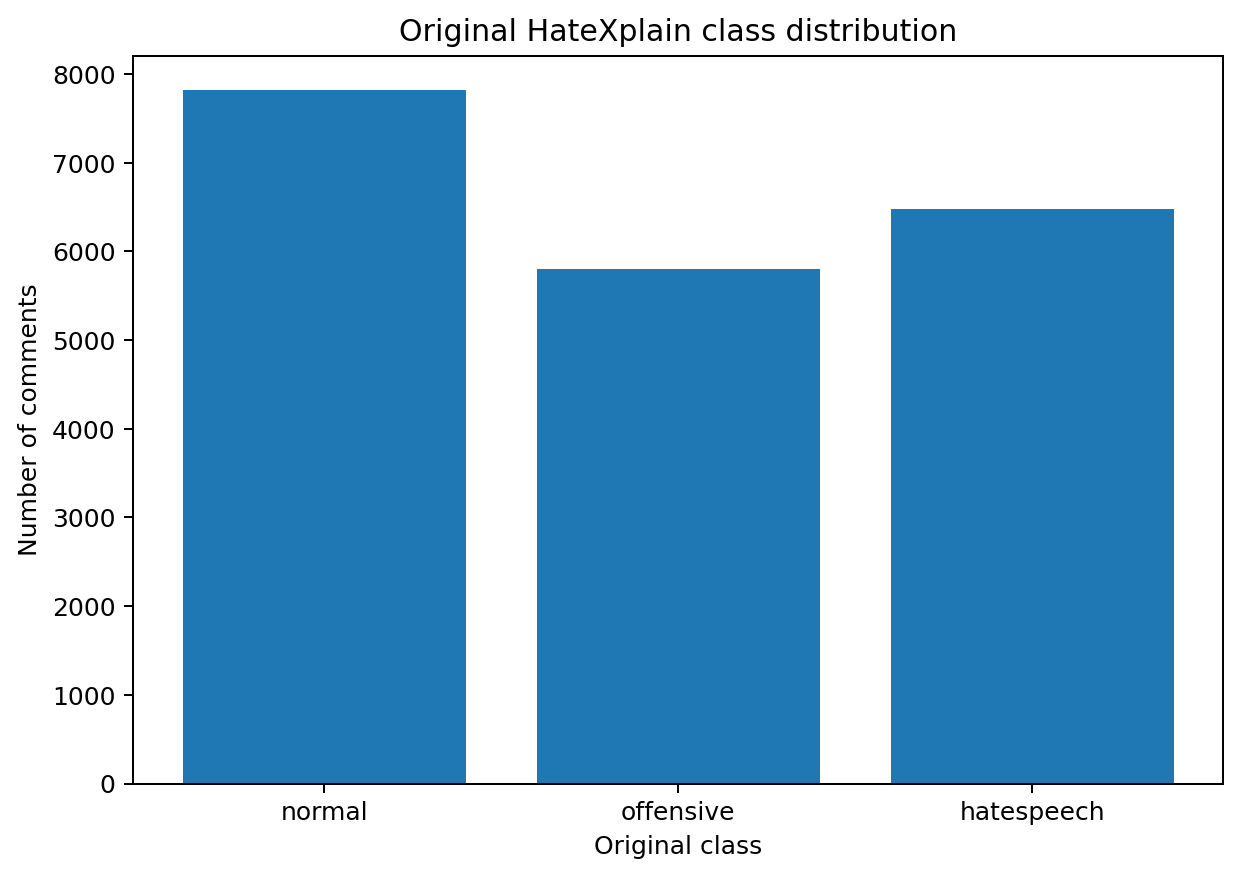

eda_label_counts.png True


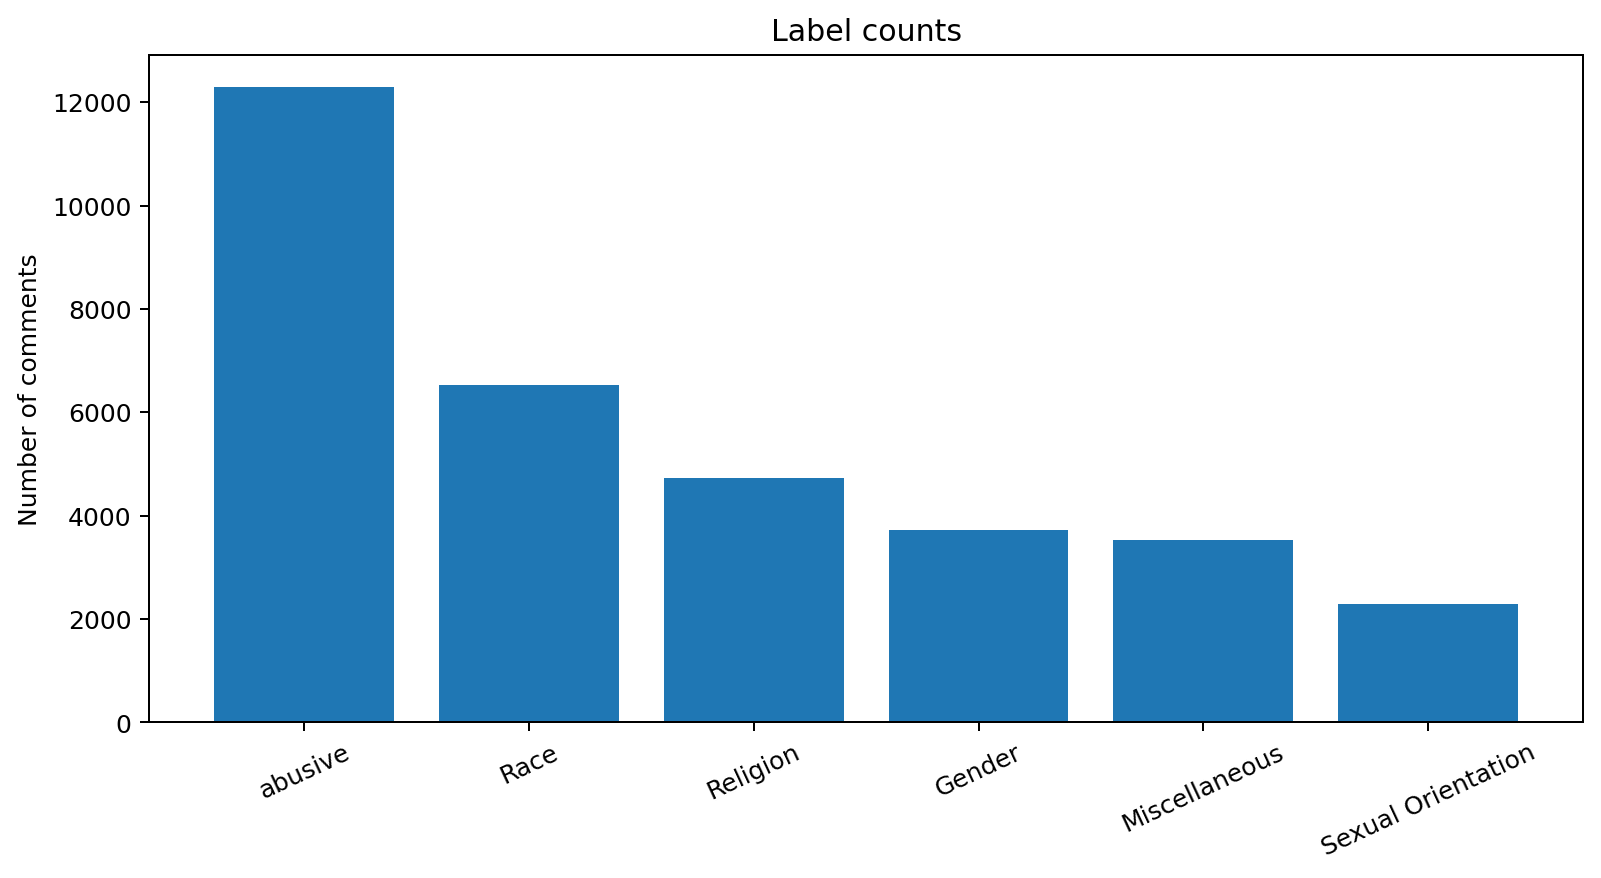

eda_text_length.png True


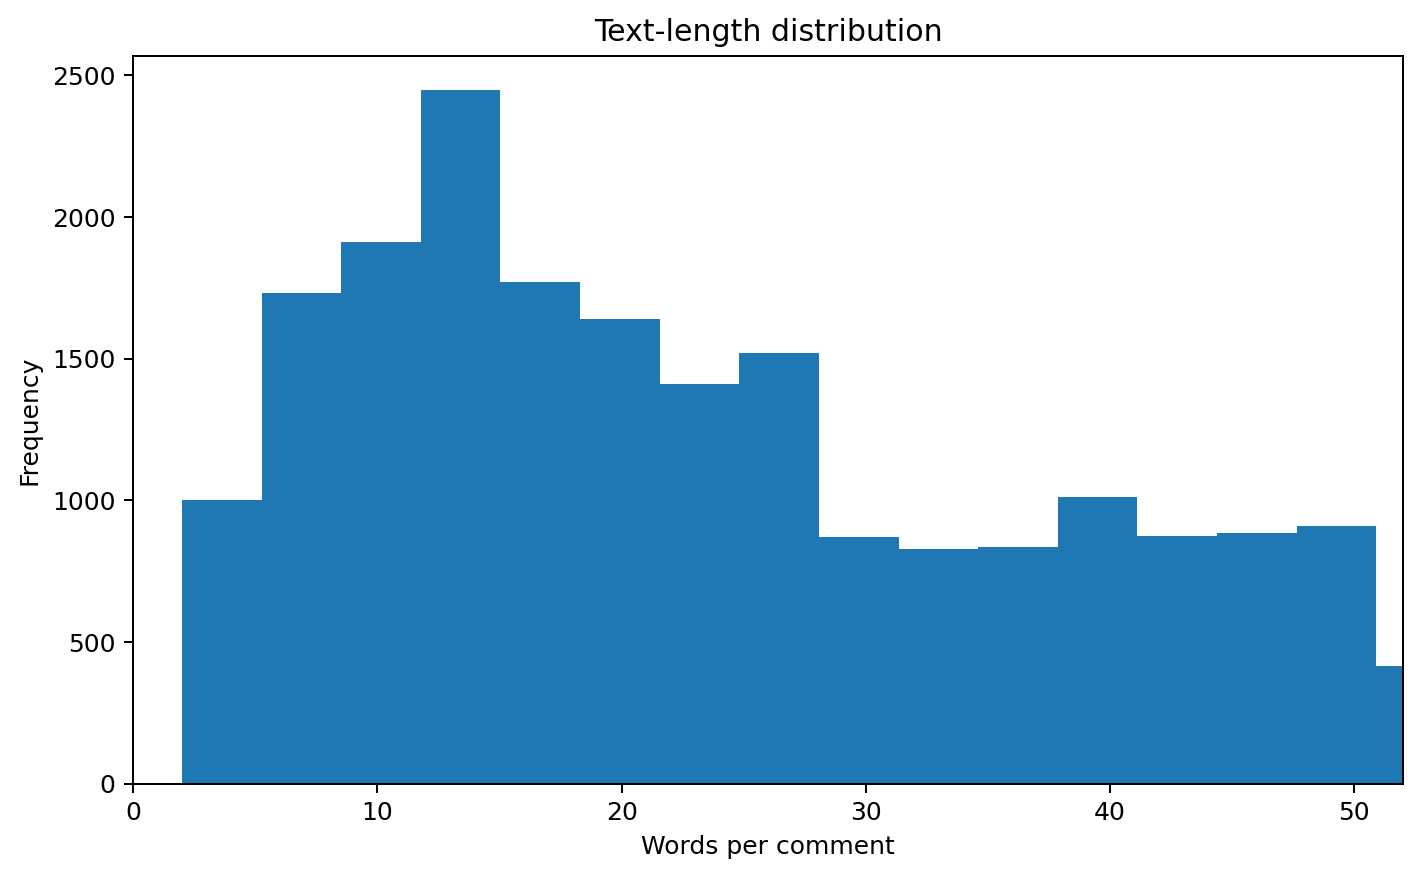

eda_label_correlation.png True


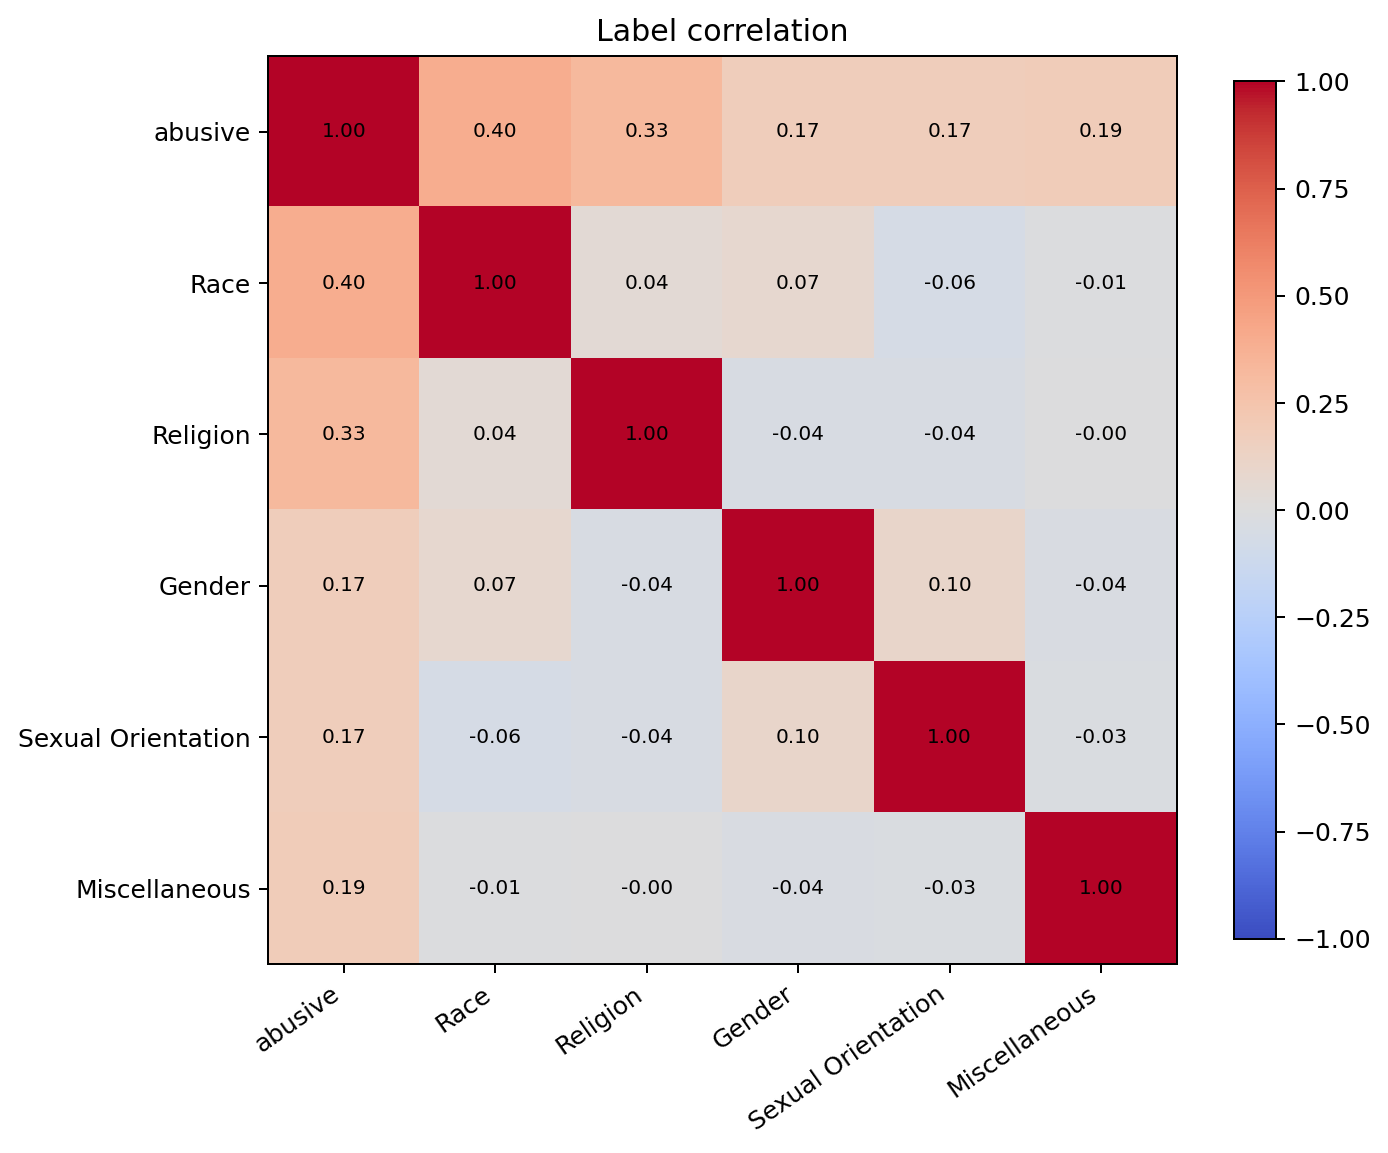

eda_positive_labels_per_comment.png True


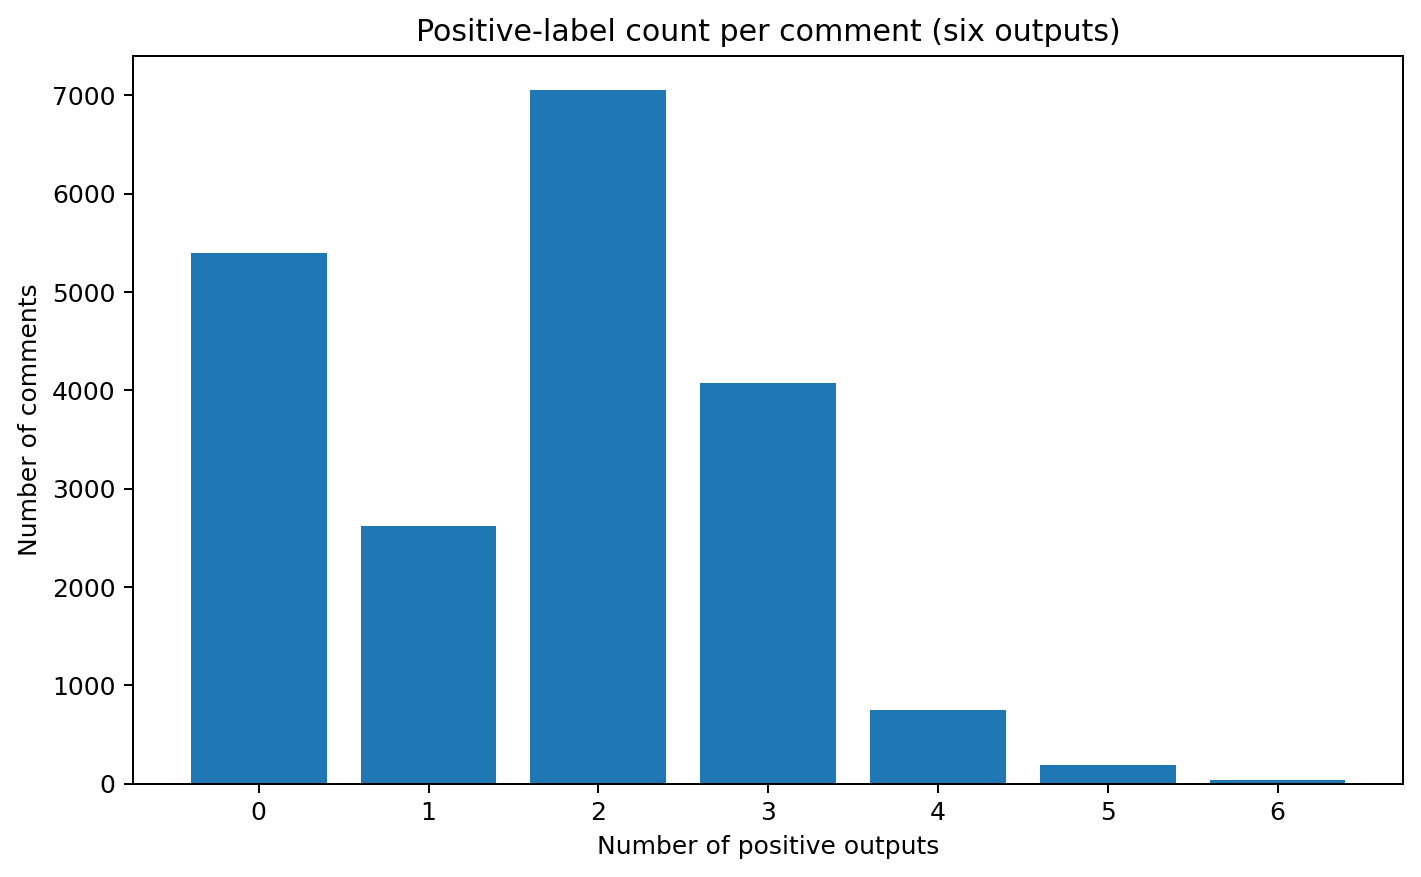

eda_target_count_distribution.png True


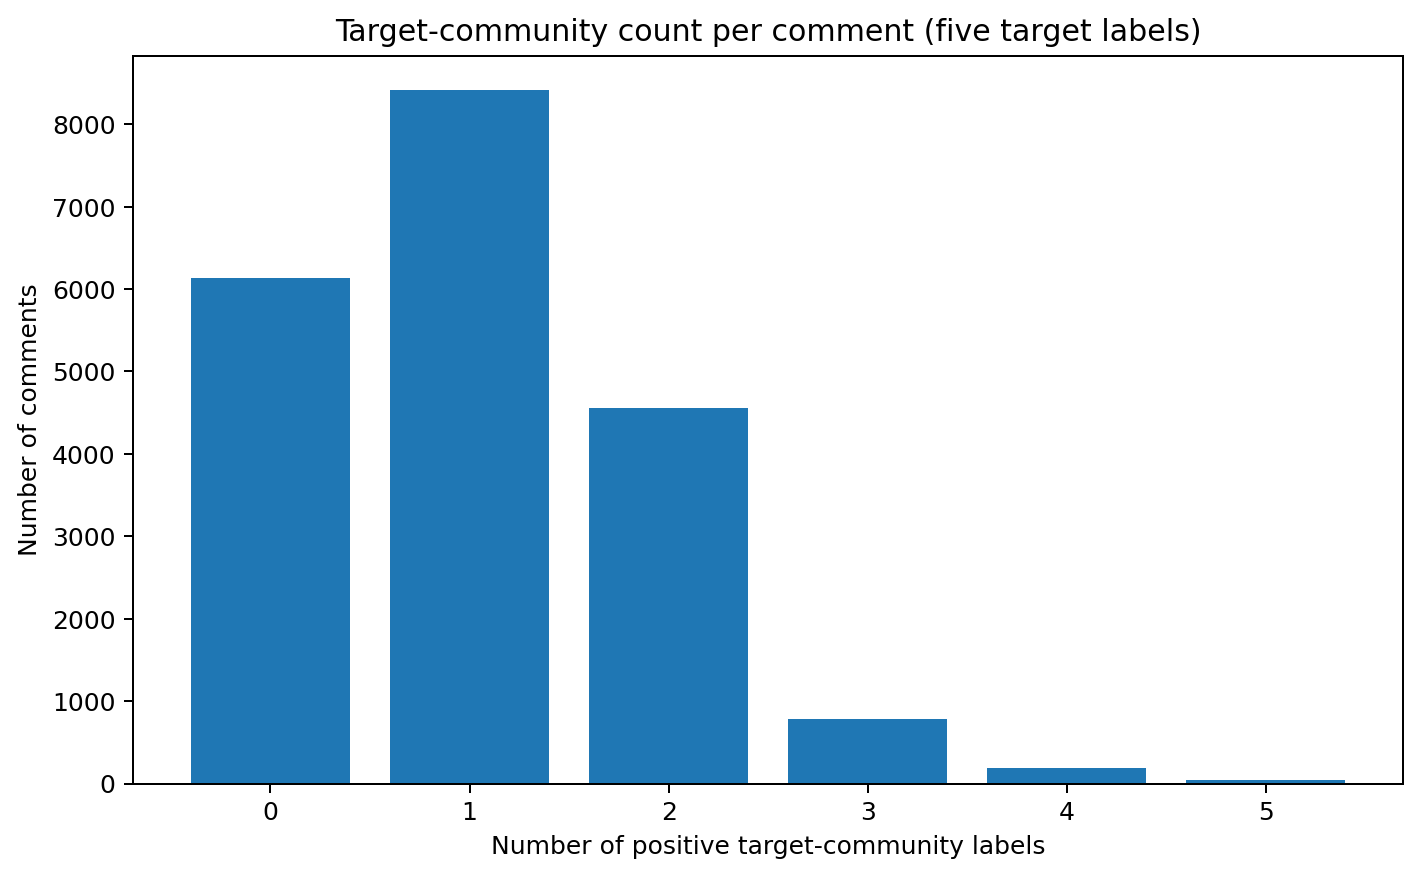

eda_targets_by_abusive_status.png True


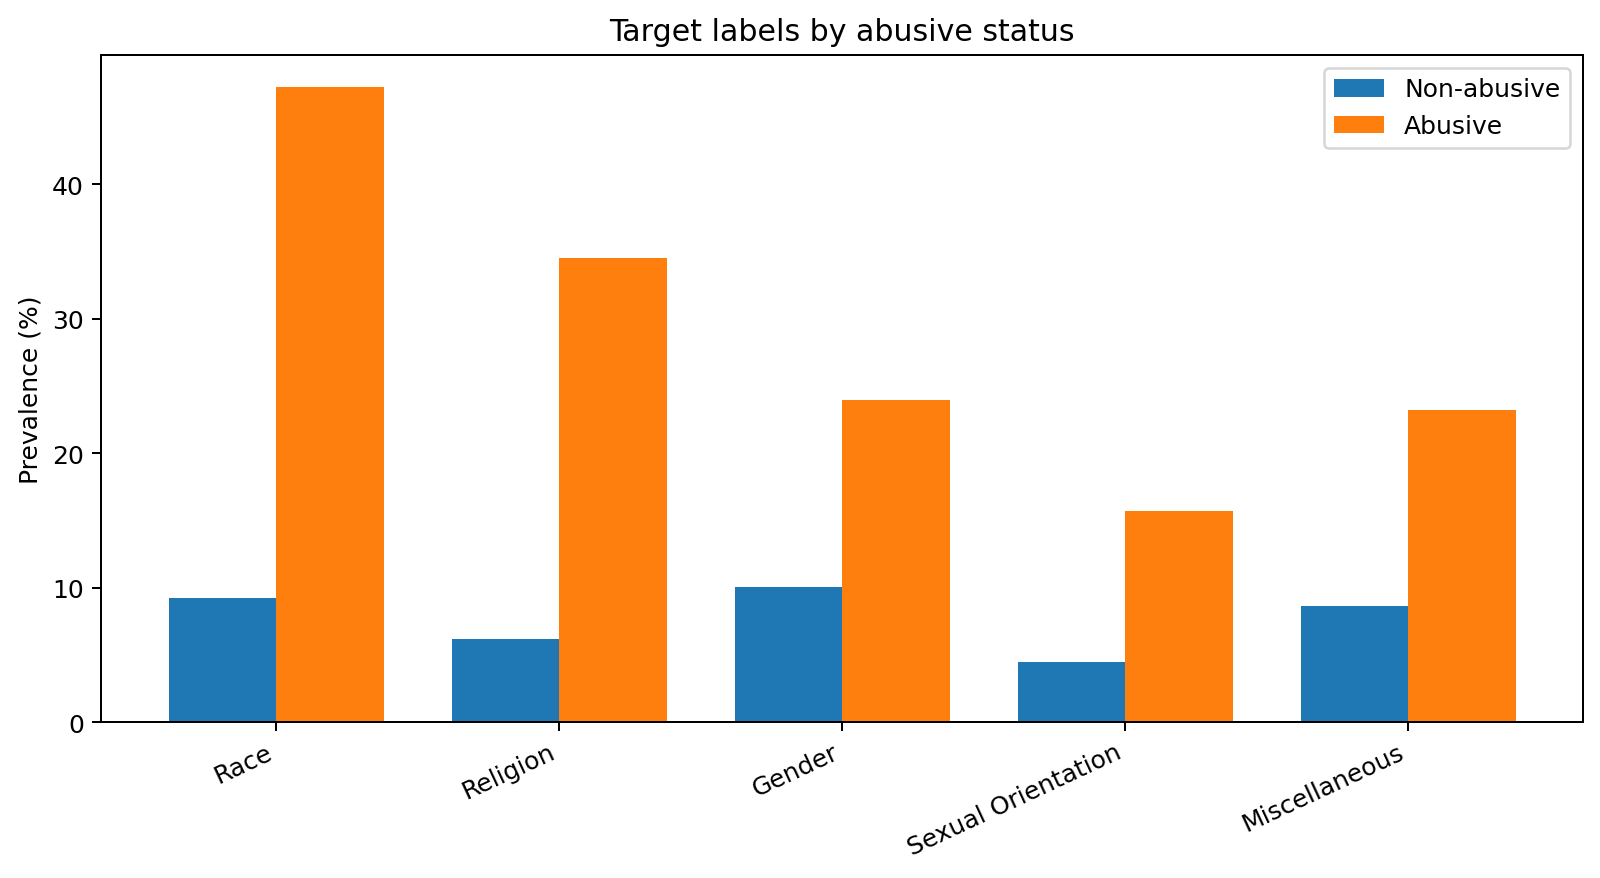

eda_length_by_original_class.png True


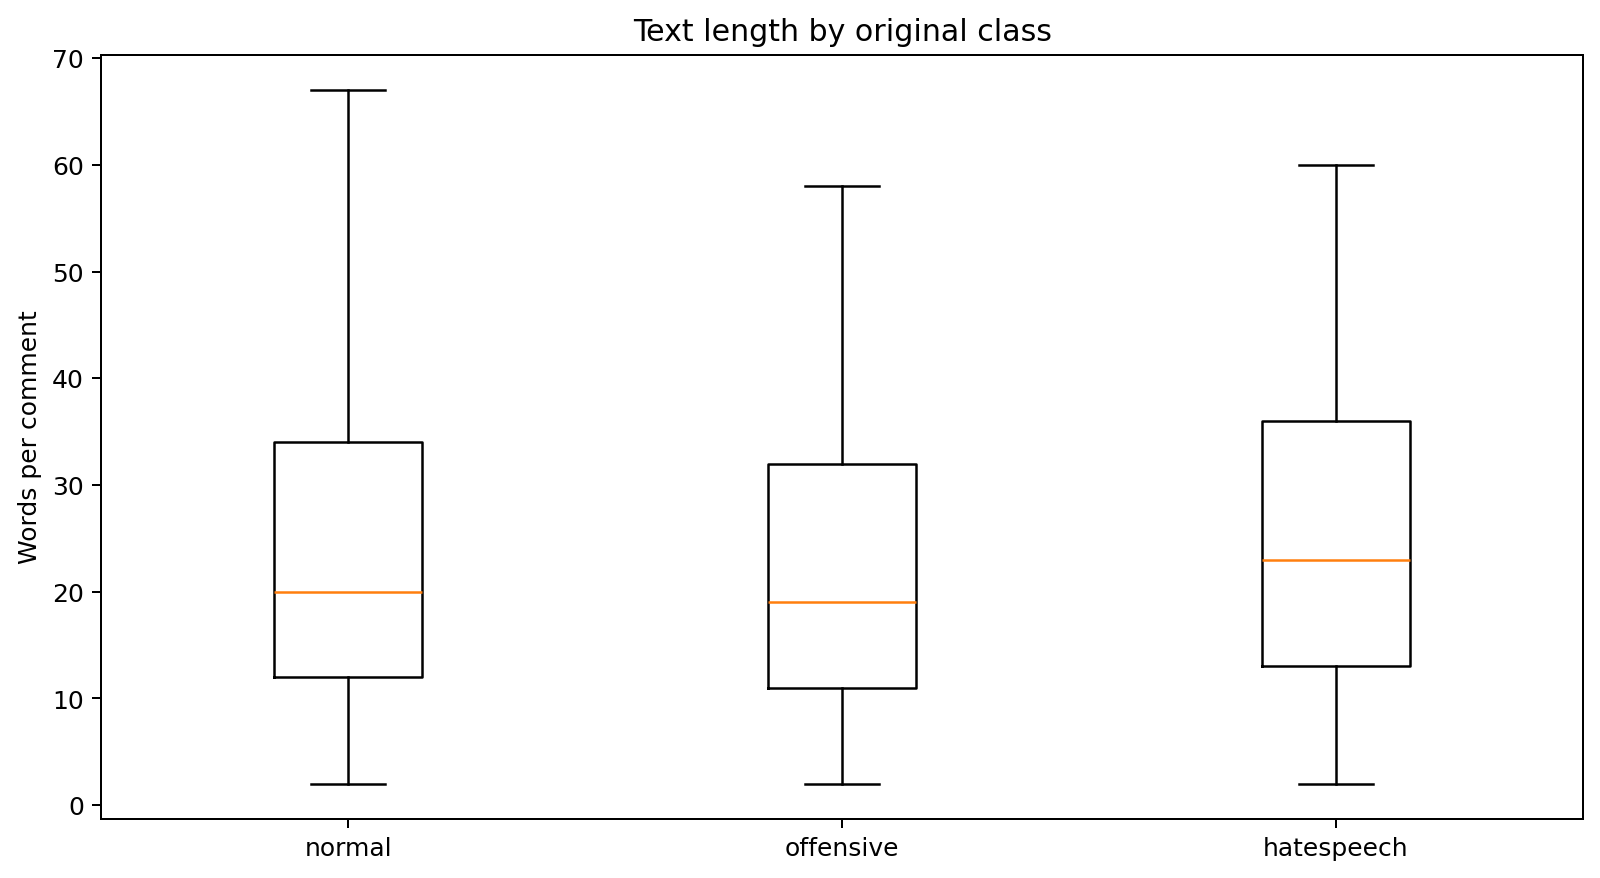

eda_split_distribution.png True


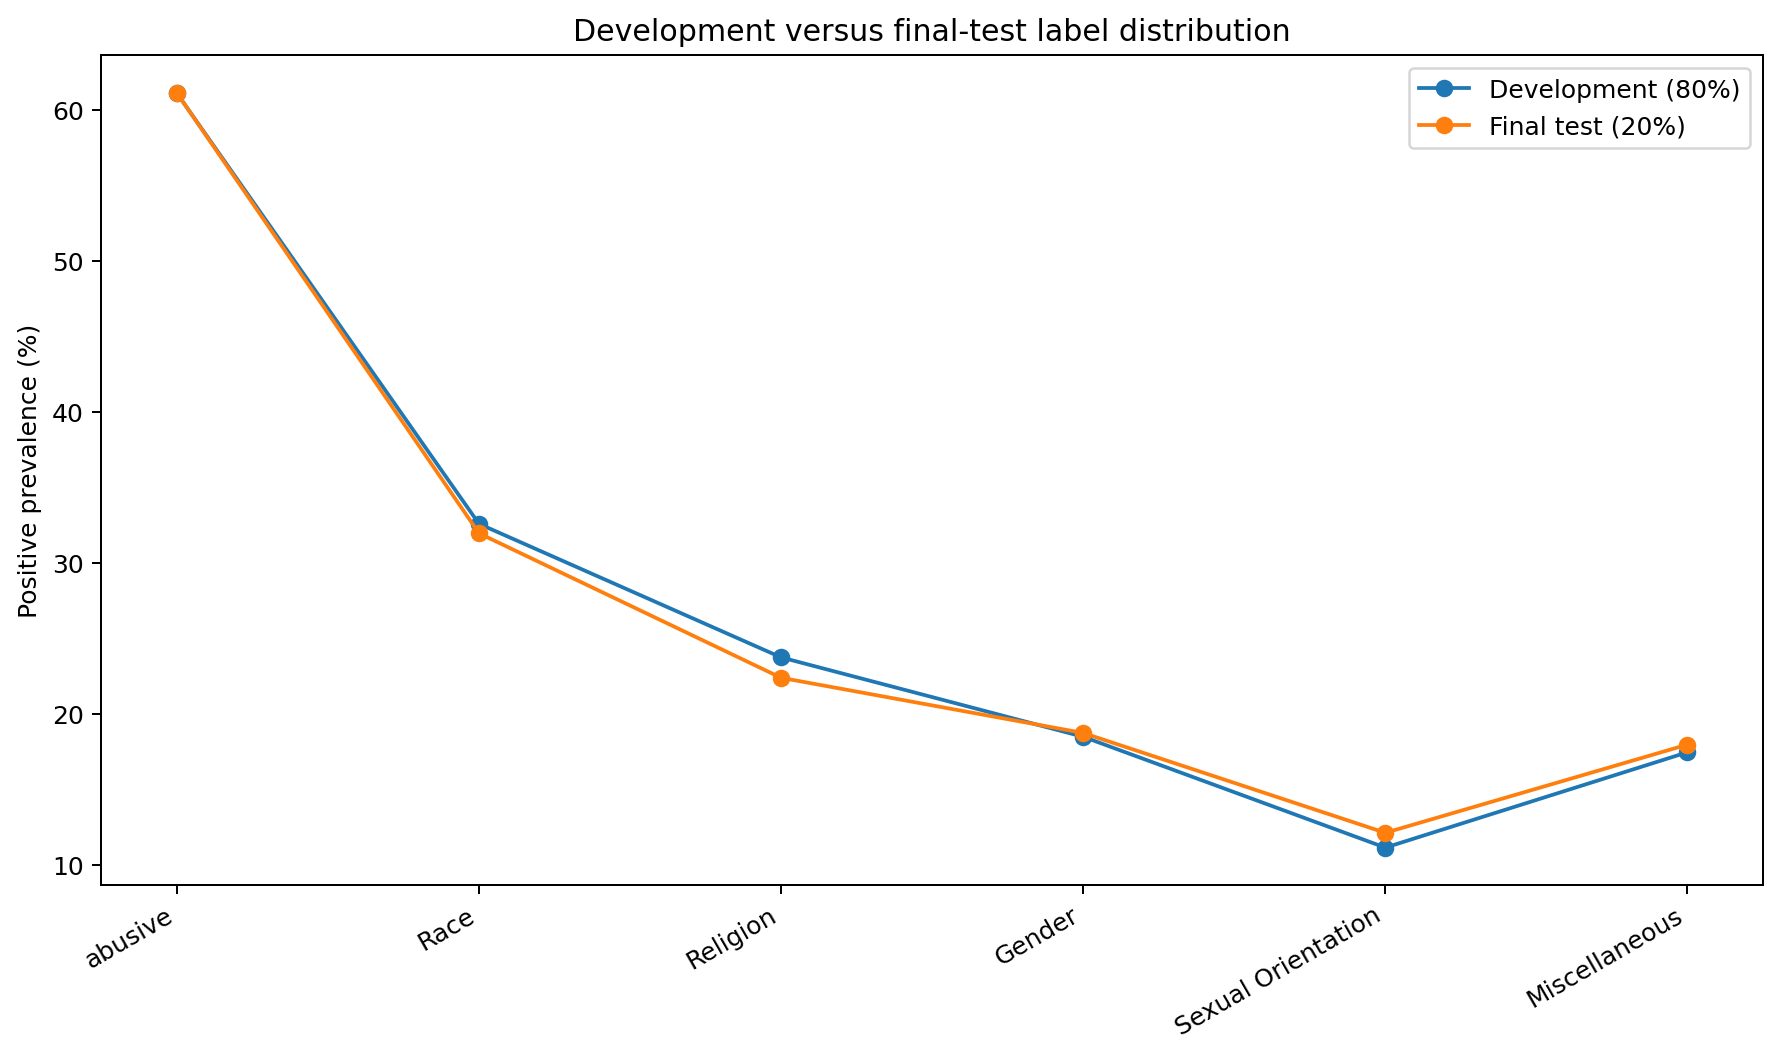

In [5]:
if RUN_EDA:
    from run_eda import main as generate_eda
    generate_eda()

eda_files = [
    'eda_original_class_distribution.png','eda_label_counts.png','eda_text_length.png',
    'eda_label_correlation.png','eda_positive_labels_per_comment.png',
    'eda_target_count_distribution.png','eda_targets_by_abusive_status.png',
    'eda_length_by_original_class.png','eda_split_distribution.png'
]
for filename in eda_files:
    path = RESULTS_DIR / filename
    print(filename, path.exists())
    if path.exists(): display(Image(filename=str(path)))


### EDA interpretation

The EDA is dataset evidence. Target labels can occur in normal posts, and harmful posts can exist without a mapped target. The split chart checks the 80/20 label prevalence balance.


## 6. Preprocessing demonstration

The shared `clean_text_steps()` pipeline demonstrates contraction expansion, negation preservation, and evasion normalisation. The final system uses deterministic built-in preprocessing and does not download NLTK resources at runtime.


In [6]:
for i, text in enumerate(df[text_col].head(3), 1):
    print(f'--- Example {i} ---')
    for name, value in clean_text_steps(text).items():
        print(name, '=>', value)


--- Example 1 ---
0. Original => 0 u0 lmao wow fuck you too 😂 😂
1. Lowercase => 0 u0 lmao wow fuck you too 😂 😂
1b. Expand contractions / preserve negation => 0 u0 lmao wow fuck you too 😂 😂
2. Remove URLs / HTML => 0 u0 lmao wow fuck you too 😂 😂
3. Evasion normalization (leetspeak, spaced letters, repeats) => 0 uo lmao wow fuck you too 😂 😂
4. Remove remaining punctuation / numbers / special characters => uo lmao wow fuck you too
5. Tokenization => uo | lmao | wow | fuck | you | too
6. Stopword removal => uo | lmao | wow | fuck
7. Lemmatization => uo | lmao | wow | fuck
8. Final cleaned text (fed to the model) => uo lmao wow fuck
--- Example 2 ---
0. Original => 1 0 th floor maybe wow cnn with the fakenews the body count is going to be waay bad too but we can all go home now they have the white ar <number> toting suicide shooter with huge drum mags dead on the 3 2 nd floor
1. Lowercase => 1 0 th floor maybe wow cnn with the fakenews the body count is going to be waay bad too but we can a

## 7. TF-IDF feature extraction

Logistic Regression and calibrated Linear SVM use word TF-IDF unigrams/bigrams/trigrams plus character TF-IDF 3–5 grams. Random Forest uses word TF-IDF. Vectorizers are fitted inside the training fold, not on validation/final-test text.


In [7]:
from src.train_utils import build_word_char_features
print(build_word_char_features())


FeatureUnion(transformer_list=[('word',
                                TfidfVectorizer(max_features=5000, min_df=2,
                                                ngram_range=(1, 3),
                                                sublinear_tf=True)),
                               ('char',
                                TfidfVectorizer(analyzer='char_wb',
                                                max_features=500, min_df=2,
                                                ngram_range=(3, 5),
                                                sublinear_tf=True))])


## 8. Data splitting

The preserved leakage-safe split is **80% development / 20% final test**. Expected counts are 16,086 and 4,022. The final-test partition is not used for model selection or threshold selection.


In [8]:
from src.common import prepare_data
X_dev, X_test, y_dev, y_test, labels = prepare_data(DATA_DIR, verbose=False)
print('Development:', len(X_dev), 'Final test:', len(X_test))
display(y_dev.mean().to_frame('development_prevalence'))
display(y_test.mean().to_frame('final_test_prevalence'))


Development: 16086 Final test: 4022


,development_prevalence
abusive,0.611215
Race,0.325998
Religion,0.237536
Gender,0.184943
Sexual_Orientation,0.111526
Miscellaneous,0.174686


,final_test_prevalence
abusive,0.611387
Race,0.319741
Religion,0.224018
Gender,0.187469
Sexual_Orientation,0.121333
Miscellaneous,0.179761


## 9. Five-fold model-configuration selection

Each model uses five-fold CV on the 80% development partition only. The training utility selects configurations using the primary harmful-content F1 with a small false-positive-rate penalty (`F1 - 0.5 × FPR`).


In [9]:
for filename in ['model_selection_logistic_regression.csv','model_selection_linear_svm.csv','model_selection_random_forest.csv']:
    print(filename)
    display(pd.read_csv(RESULTS_DIR / filename))


model_selection_logistic_regression.csv


,configuration,primary_f1_cv_mean,primary_f1_cv_std,benign_false_positive_rate_cv_mean,selection_utility_f1_minus_0.5_fpr
0,"C=0.5, class_weight=balanced",0.760515,0.011463,0.233935,0.643547
1,"C=1.0, class_weight=balanced",0.767122,0.010616,0.244648,0.644798
2,"C=2.0, class_weight=balanced",0.770192,0.008531,0.257438,0.641473


model_selection_linear_svm.csv


,configuration,primary_f1_cv_mean,primary_f1_cv_std,benign_false_positive_rate_cv_mean,selection_utility_f1_minus_0.5_fpr
0,"C=0.5, class_weight=balanced",0.788488,0.007999,0.406308,0.585334
1,"C=1.0, class_weight=balanced",0.785831,0.008996,0.433173,0.569245
2,"C=2.0, class_weight=balanced",0.782690,0.006526,0.464353,0.550514
3,"C=1.0, class_weight=None",0.786100,0.009502,0.436691,0.567755


model_selection_random_forest.csv


,configuration,primary_f1_cv_mean,primary_f1_cv_std,benign_false_positive_rate_cv_mean,selection_utility_f1_minus_0.5_fpr
0,"trees=60, depth=20, leaf=1, balanced",0.708260,0.015309,0.158929,0.628796
1,"trees=90, depth=35, leaf=2, balanced",0.714040,0.016288,0.161656,0.633212
2,"trees=120, depth=45, leaf=3, none",0.787075,0.004123,0.693315,0.440417


## 10. Separate five-fold OOF threshold selection

After model selection, a separate five-fold OOF process on the full development partition produces probabilities for threshold selection. There is one saved threshold for `abusive` and an independent threshold for each target label. The final test is never used for threshold selection.


In [10]:
for filename in ['threshold_evidence_logistic_regression.csv','threshold_evidence_linear_svm.csv','threshold_evidence_random_forest.csv']:
    print(filename)
    display(pd.read_csv(RESULTS_DIR / filename)[['label','threshold','objective','f1','precision','recall','false_positive_rate']])

for name, path in available_models().items():
    print(name, load_model(path)['thresholds'])


threshold_evidence_logistic_regression.csv


,label,threshold,objective,f1,precision,recall,false_positive_rate
0,abusive,0.37,harmful-content F1 with minimum precision floo...,0.795096,0.753920,0.841029,0.431564
1,Race,0.46,label-specific F1,0.720498,0.675054,0.772502,0.179856
2,Religion,0.47,label-specific F1,0.810271,0.757279,0.871238,0.086996
3,Gender,0.58,label-specific F1,0.512484,0.501124,0.524370,0.118450
4,Sexual_Orientation,0.53,label-specific F1,0.764645,0.714632,0.822185,0.041212
5,Miscellaneous,0.56,label-specific F1,0.489365,0.444380,0.544484,0.144095


threshold_evidence_linear_svm.csv


,label,threshold,objective,f1,precision,recall,false_positive_rate
0,abusive,0.49,harmful-content F1 with minimum precision floo...,0.789331,0.754357,0.827705,0.423729
1,Race,0.37,label-specific F1,0.723352,0.711414,0.735698,0.144346
2,Religion,0.30,label-specific F1,0.804175,0.765555,0.846899,0.080799
3,Gender,0.25,label-specific F1,0.493766,0.460331,0.532437,0.141637
4,Sexual_Orientation,0.23,label-specific F1,0.750662,0.714718,0.790412,0.039603
5,Miscellaneous,0.23,label-specific F1,0.468959,0.416644,0.536299,0.158933


threshold_evidence_random_forest.csv


,label,threshold,objective,f1,precision,recall,false_positive_rate
0,abusive,0.47,harmful-content F1 with minimum precision floo...,0.771217,0.770668,0.771766,0.361049
1,Race,0.49,label-specific F1,0.725162,0.735912,0.714722,0.124055
2,Religion,0.48,label-specific F1,0.804978,0.767442,0.846375,0.079902
3,Gender,0.48,label-specific F1,0.536025,0.498124,0.580168,0.132637
4,Sexual_Orientation,0.48,label-specific F1,0.784915,0.735739,0.841137,0.037923
5,Miscellaneous,0.49,label-specific F1,0.502080,0.489520,0.515302,0.113739


Logistic Regression {'abusive': 0.37, 'Race': 0.46, 'Religion': 0.47, 'Gender': 0.58, 'Sexual_Orientation': 0.53, 'Miscellaneous': 0.56}
Linear SVM {'abusive': 0.49, 'Race': 0.37, 'Religion': 0.3, 'Gender': 0.25, 'Sexual_Orientation': 0.23, 'Miscellaneous': 0.23}


Random Forest {'abusive': 0.47, 'Race': 0.49, 'Religion': 0.48, 'Gender': 0.48, 'Sexual_Orientation': 0.48, 'Miscellaneous': 0.49}


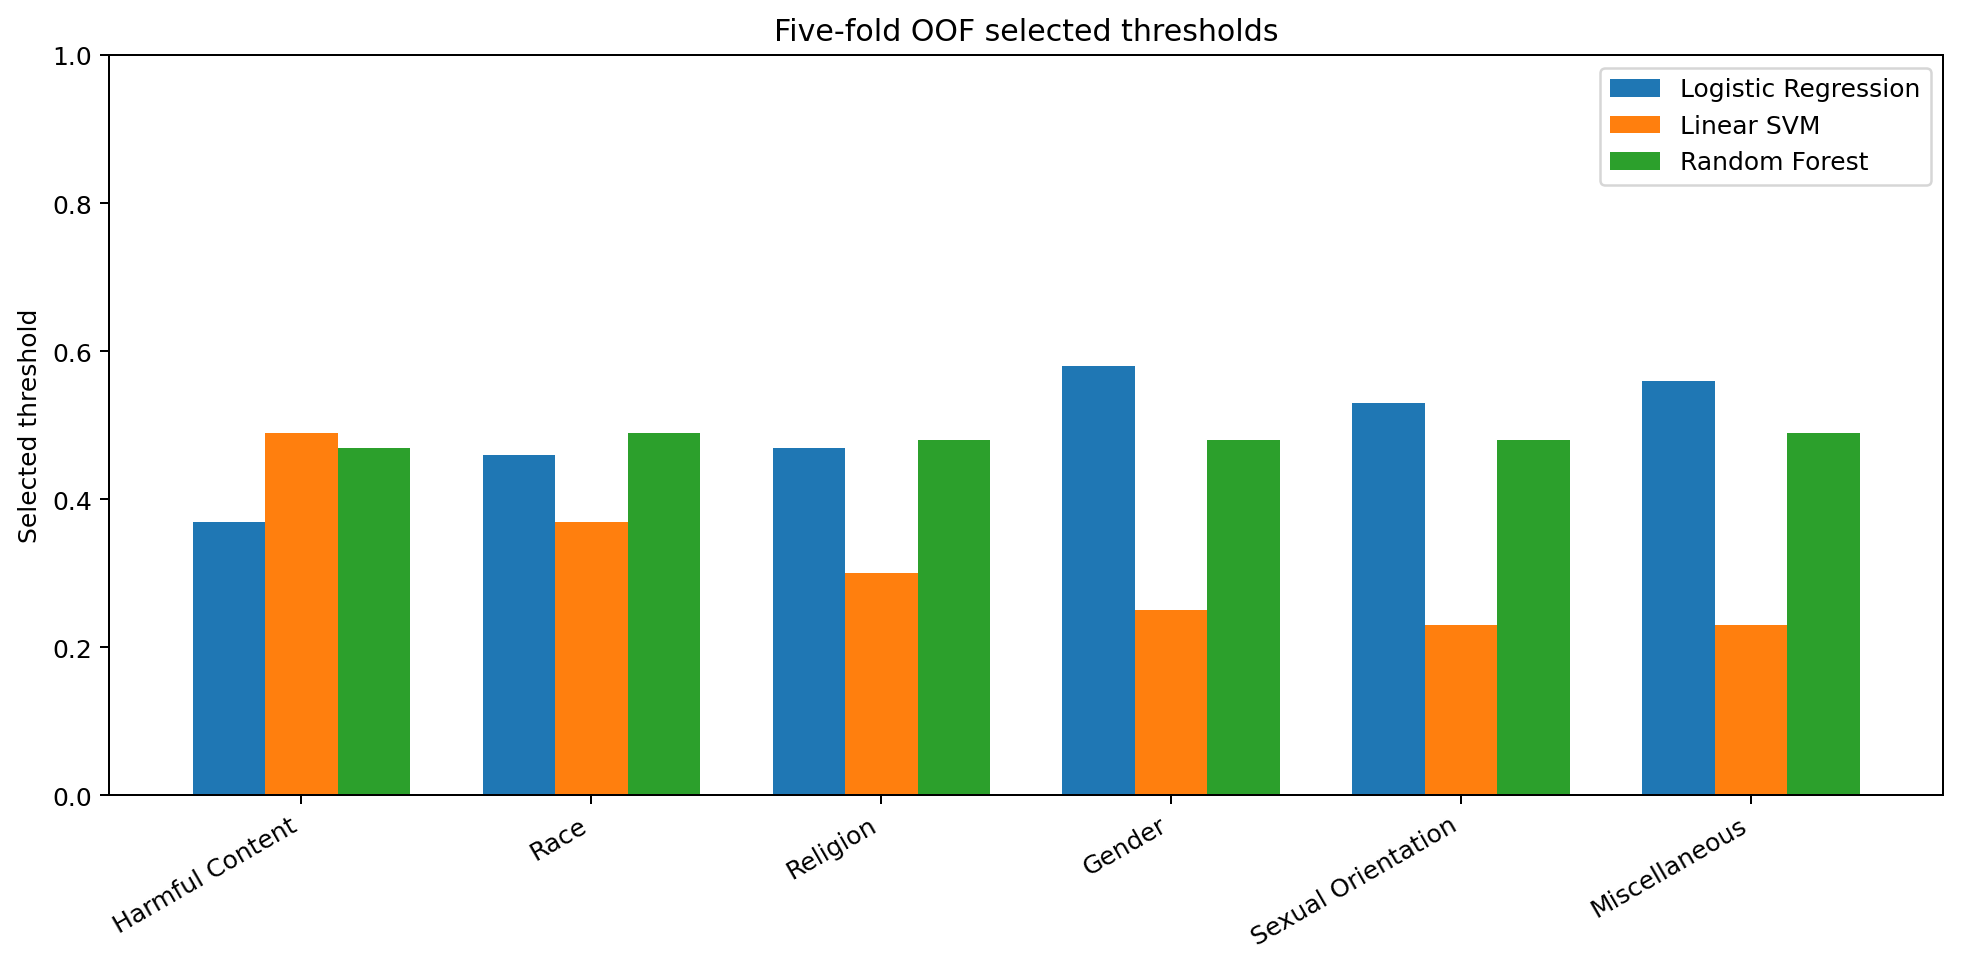

In [11]:
if (RESULTS_DIR / 'threshold_comparison.png').exists():
    display(Image(filename=str(RESULTS_DIR / 'threshold_comparison.png')))


## 11. Final results

The final-test evidence is loaded from `model_scores.csv`. Primary harmful-content metrics are reported separately from six-label multilabel metrics.


In [12]:
scores = pd.read_csv(RESULTS_DIR / 'model_scores.csv')
display(scores[['model','harmful_precision','harmful_recall','harmful_f1',
                'harmful_false_positive_rate','harmful_false_negative_rate',
                'f1_micro','f1_macro','subset_accuracy','hamming_loss',
                'train_time_sec','predict_time_sec','threshold_abusive']])


,model,harmful_precision,harmful_recall,harmful_f1,harmful_false_positive_rate,harmful_false_negative_rate,f1_micro,f1_macro,subset_accuracy,hamming_loss,train_time_sec,predict_time_sec,threshold_abusive
0,Logistic Regression,0.7597,0.8524,0.8034,0.4242,0.1476,0.7245,0.6927,0.3705,0.1616,4.112,0.3076,0.37
1,Linear SVM,0.7628,0.8451,0.8019,0.4133,0.1549,0.7126,0.6783,0.3655,0.1664,5.928,0.3514,0.49
2,Random Forest,0.7729,0.7654,0.7691,0.3538,0.2346,0.7104,0.6897,0.3702,0.1622,5.339,0.3039,0.47


### Result charts

`compare_models.py` and `generate_final_artifacts.py` consume saved evidence only; they do not retrain models or generate a different final-test result set.


primary_metrics_comparison.png True


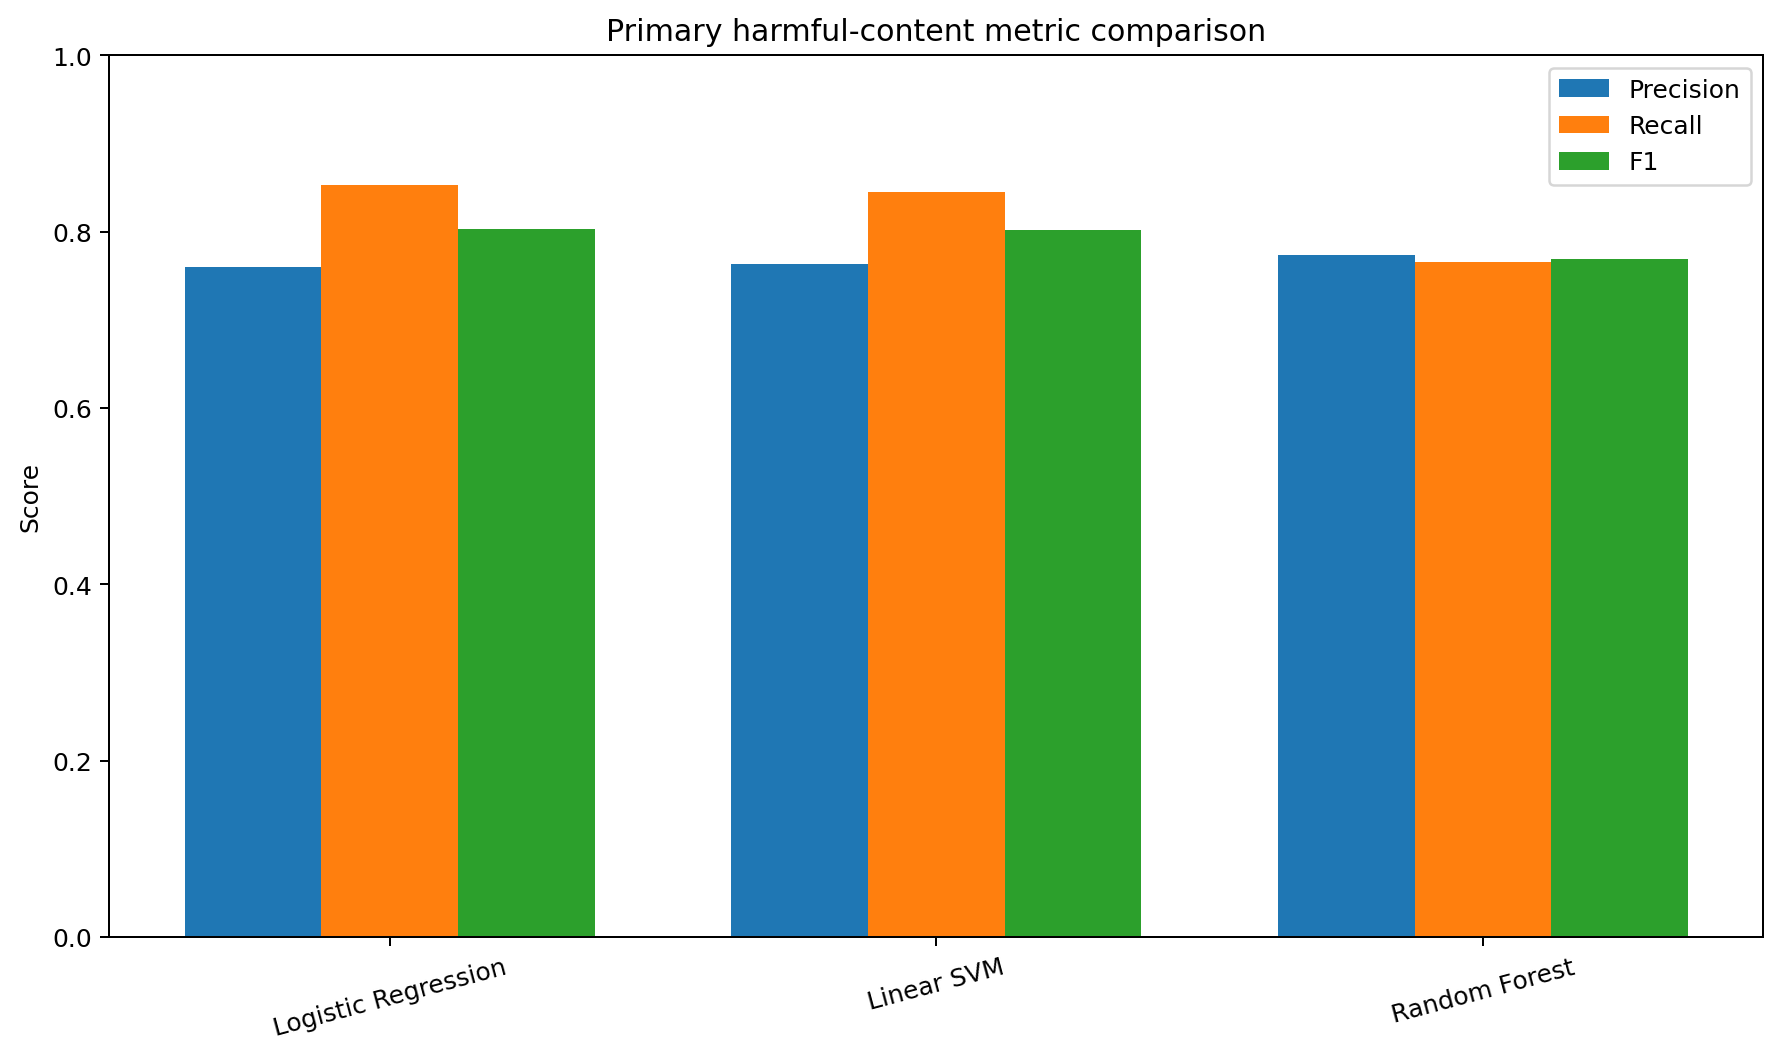

primary_error_rates.png True


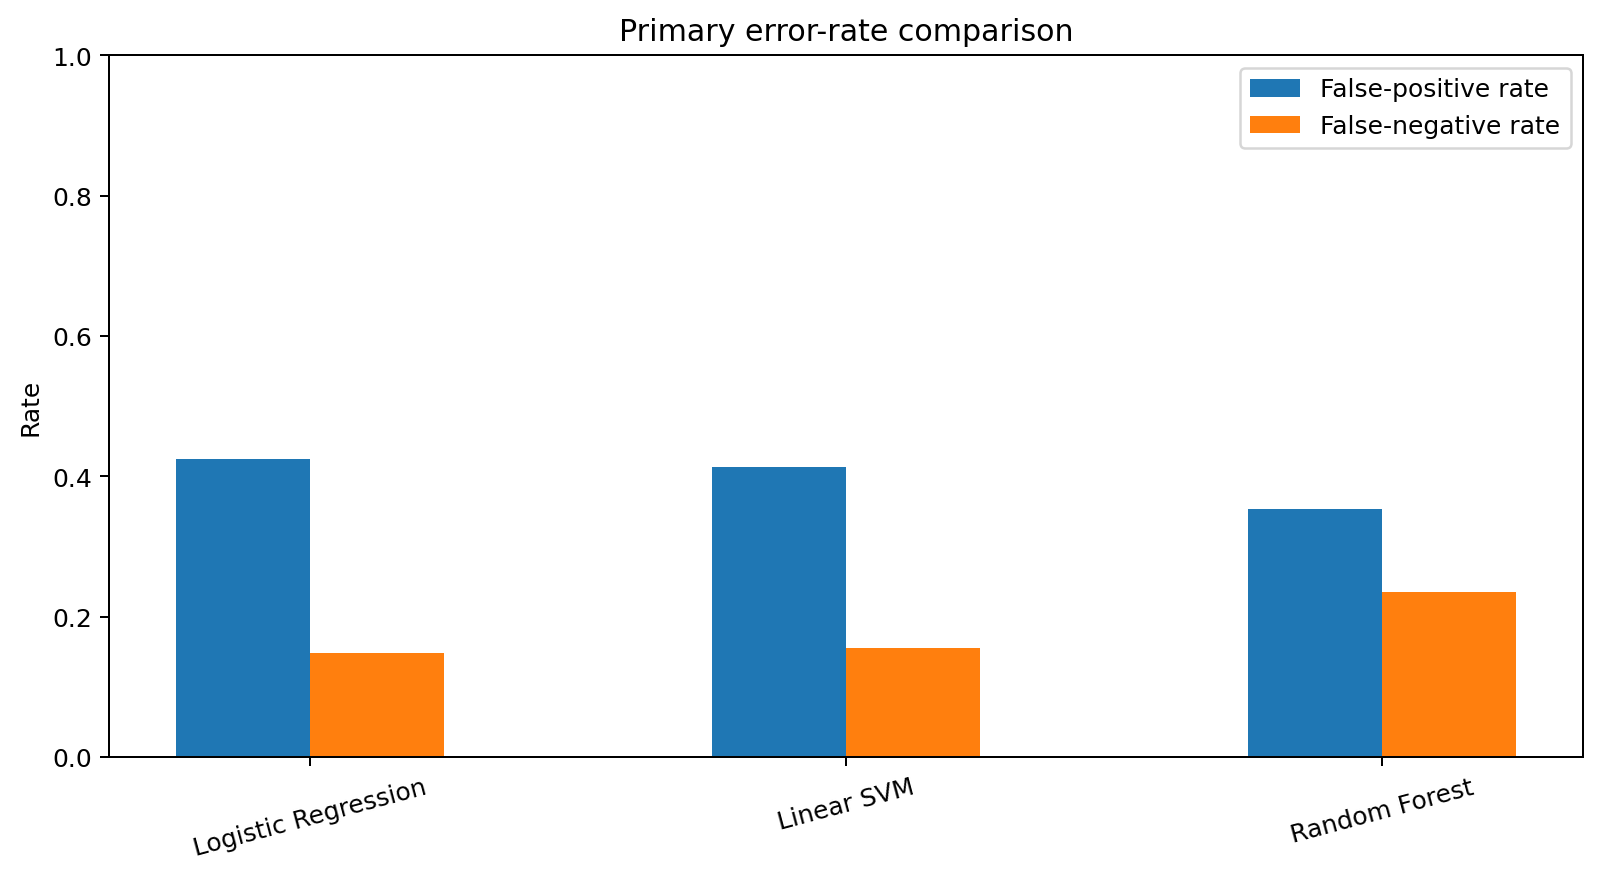

per_label_f1_heatmap.png True


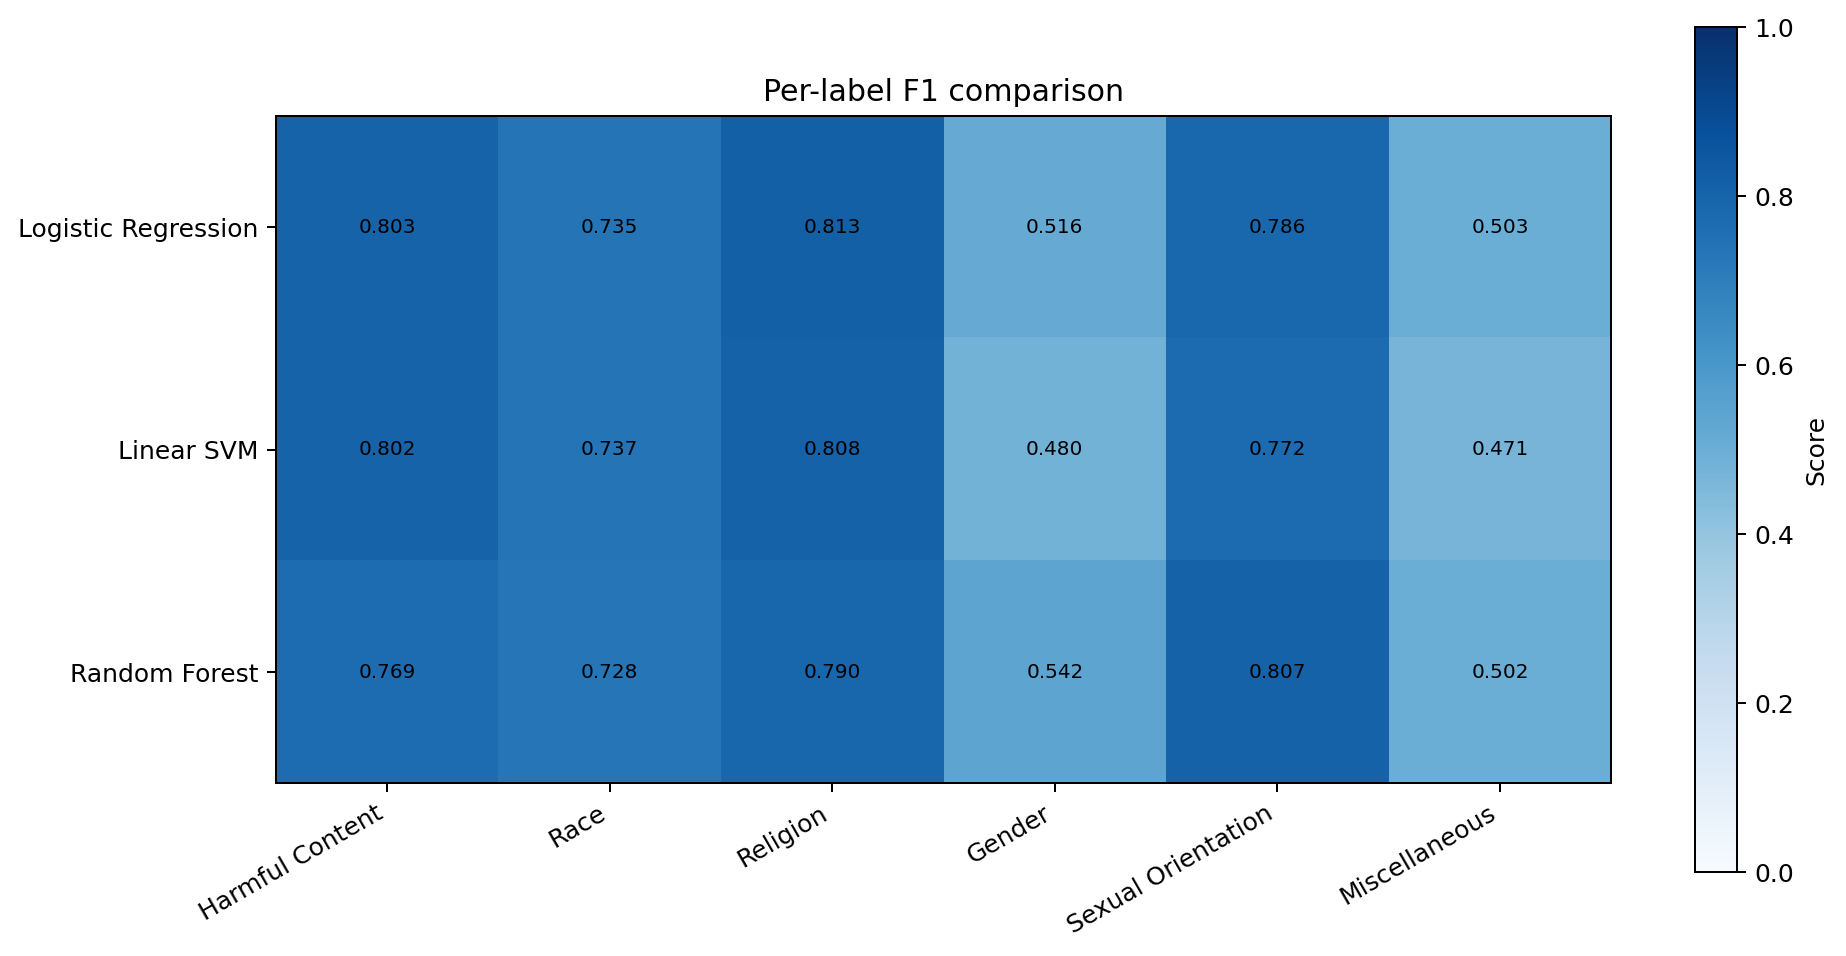

per_label_precision_heatmap.png True


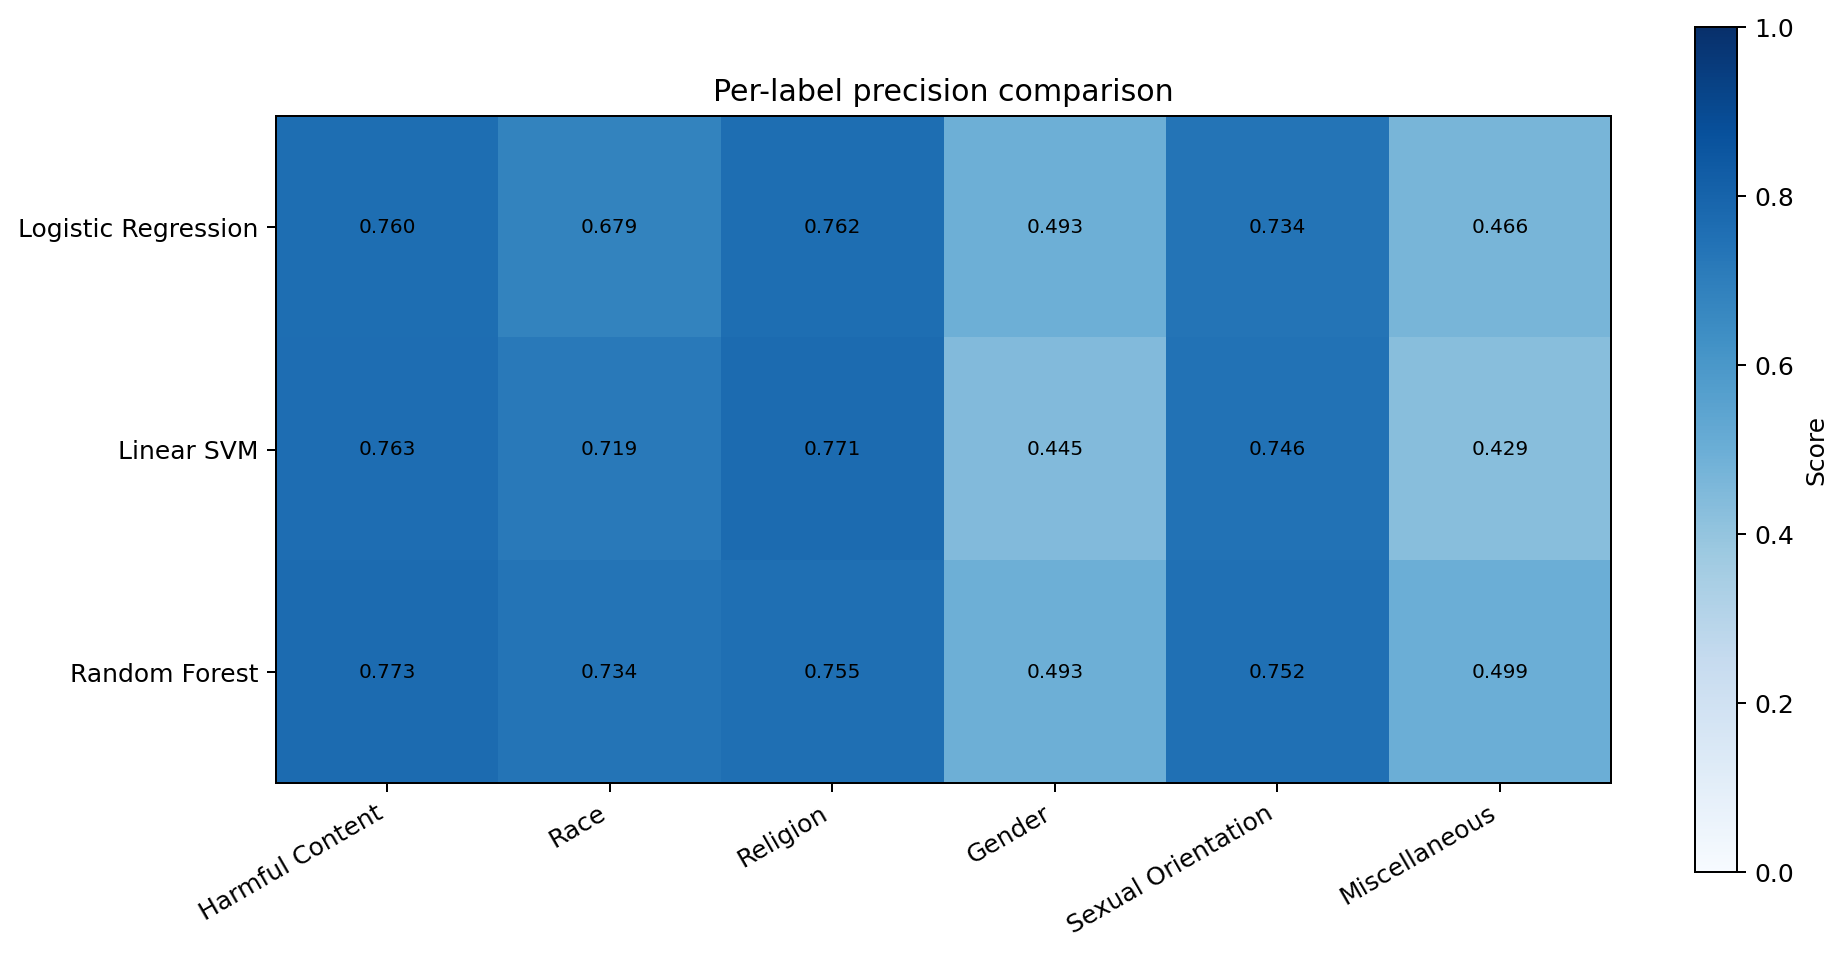

per_label_recall_heatmap.png True


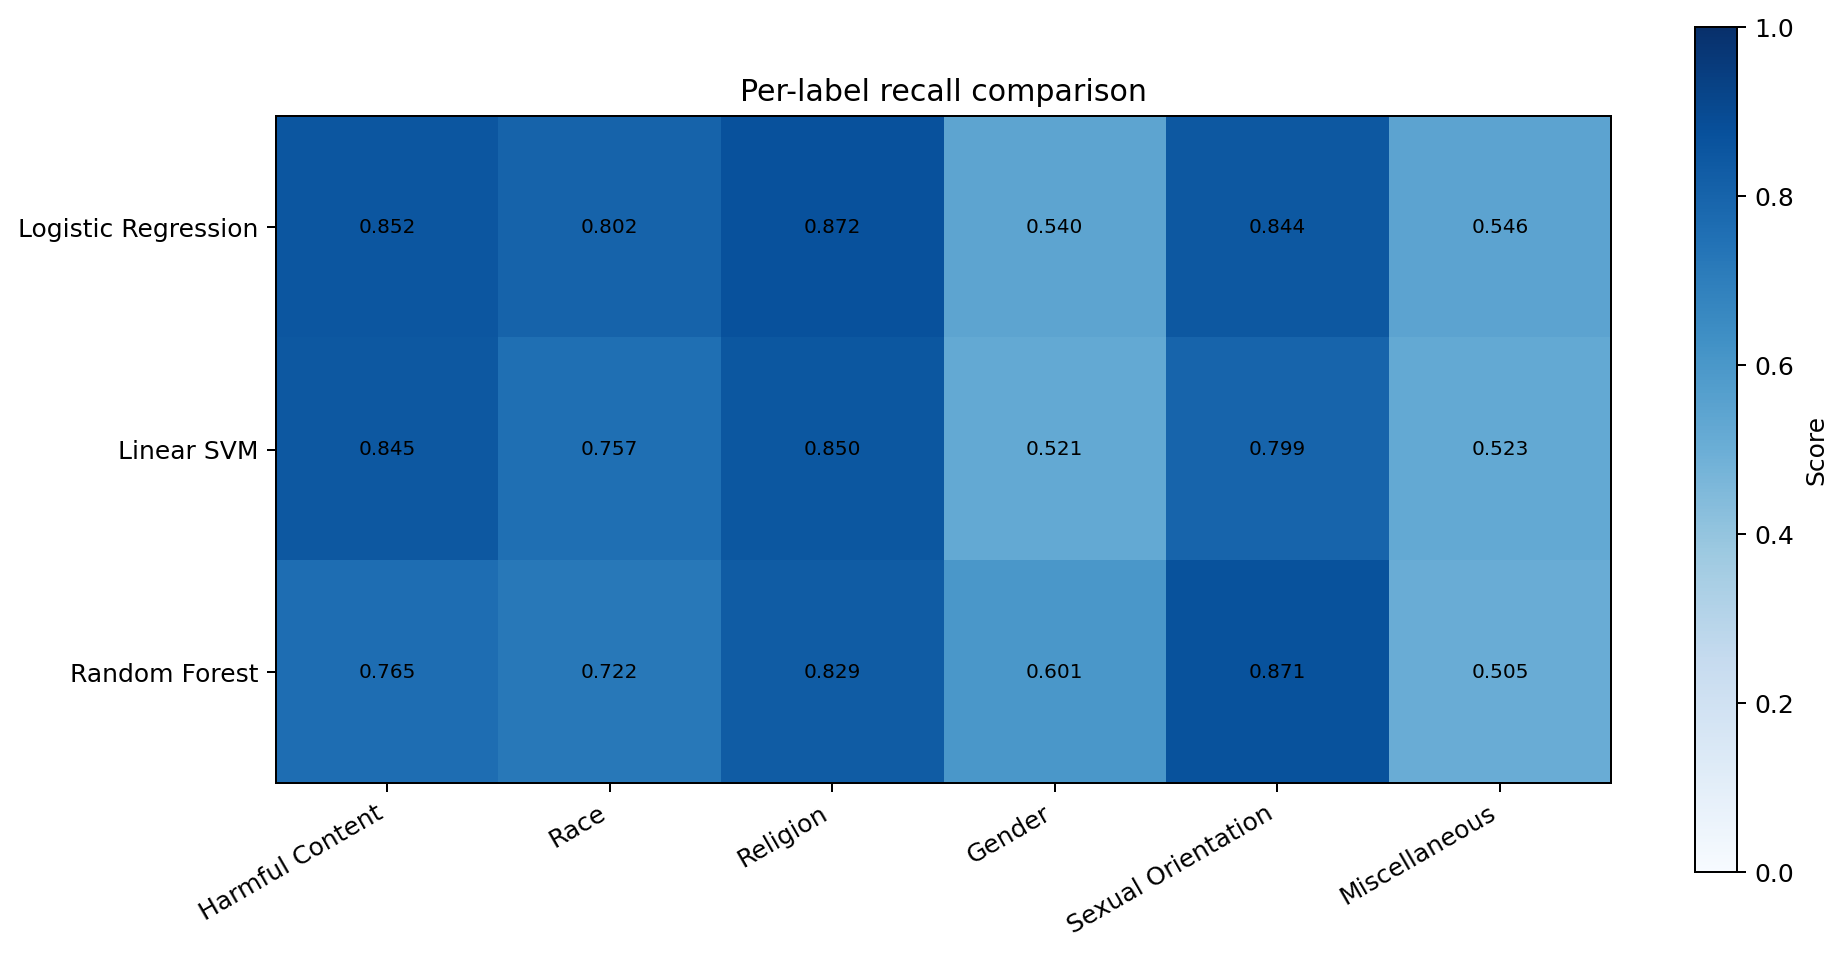

threshold_comparison.png True


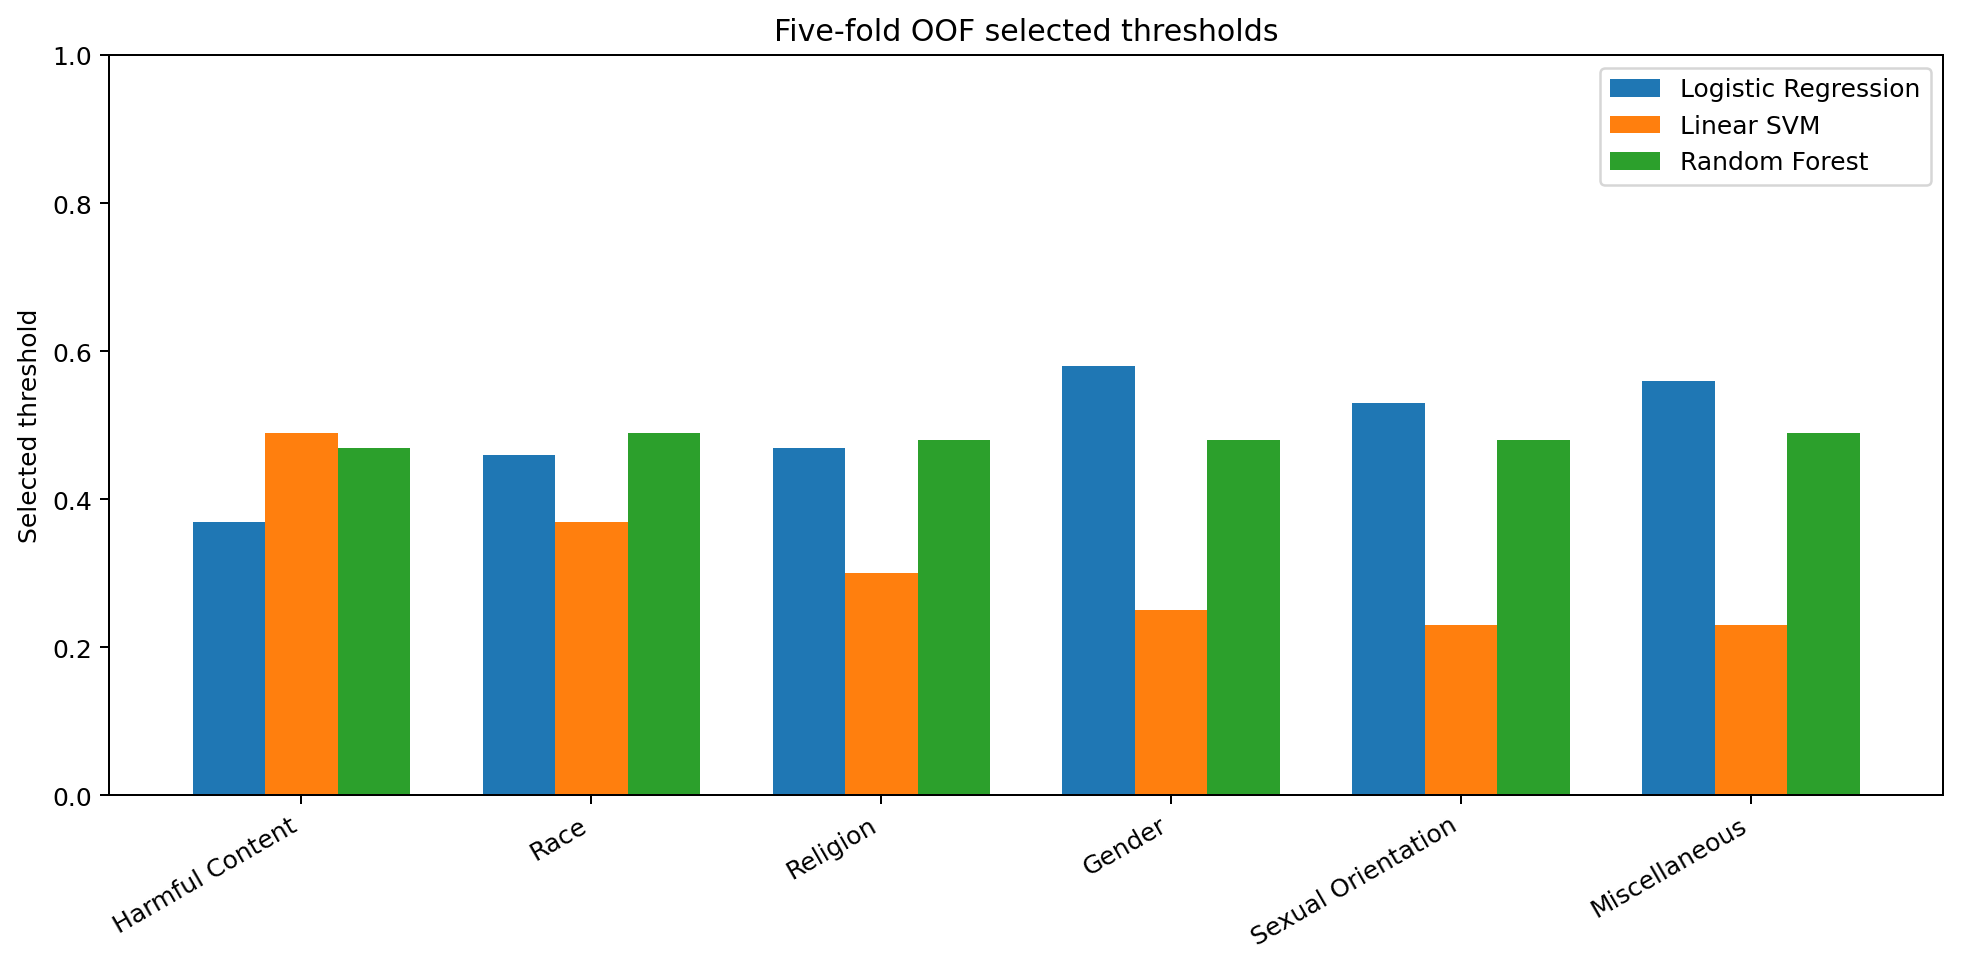

oof_vs_final_test_f1.png True


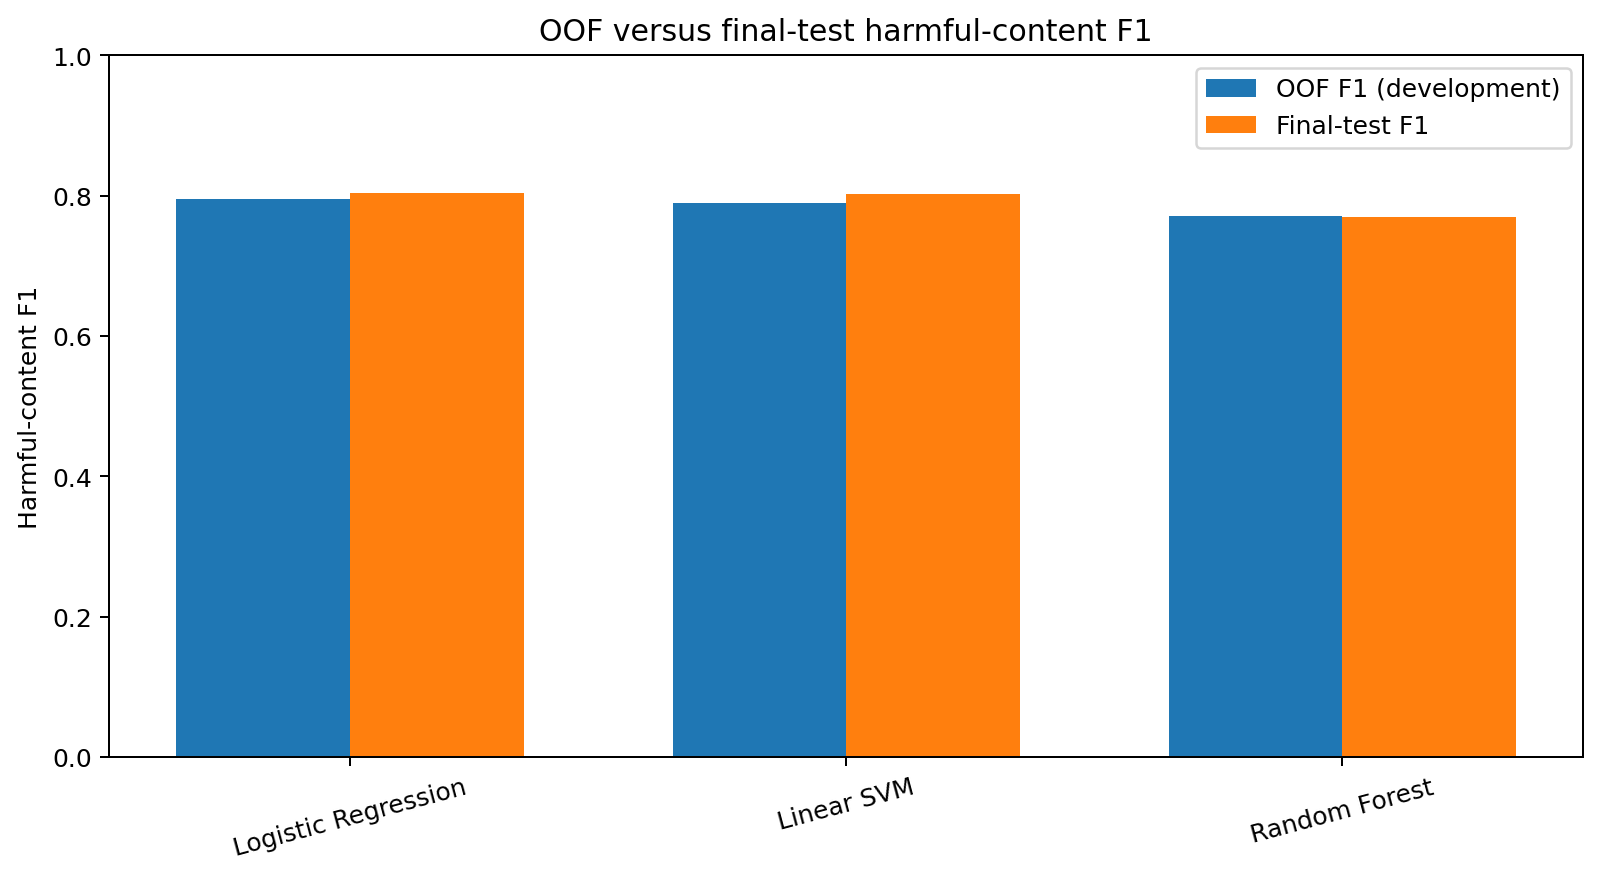

model_timing_comparison.png True


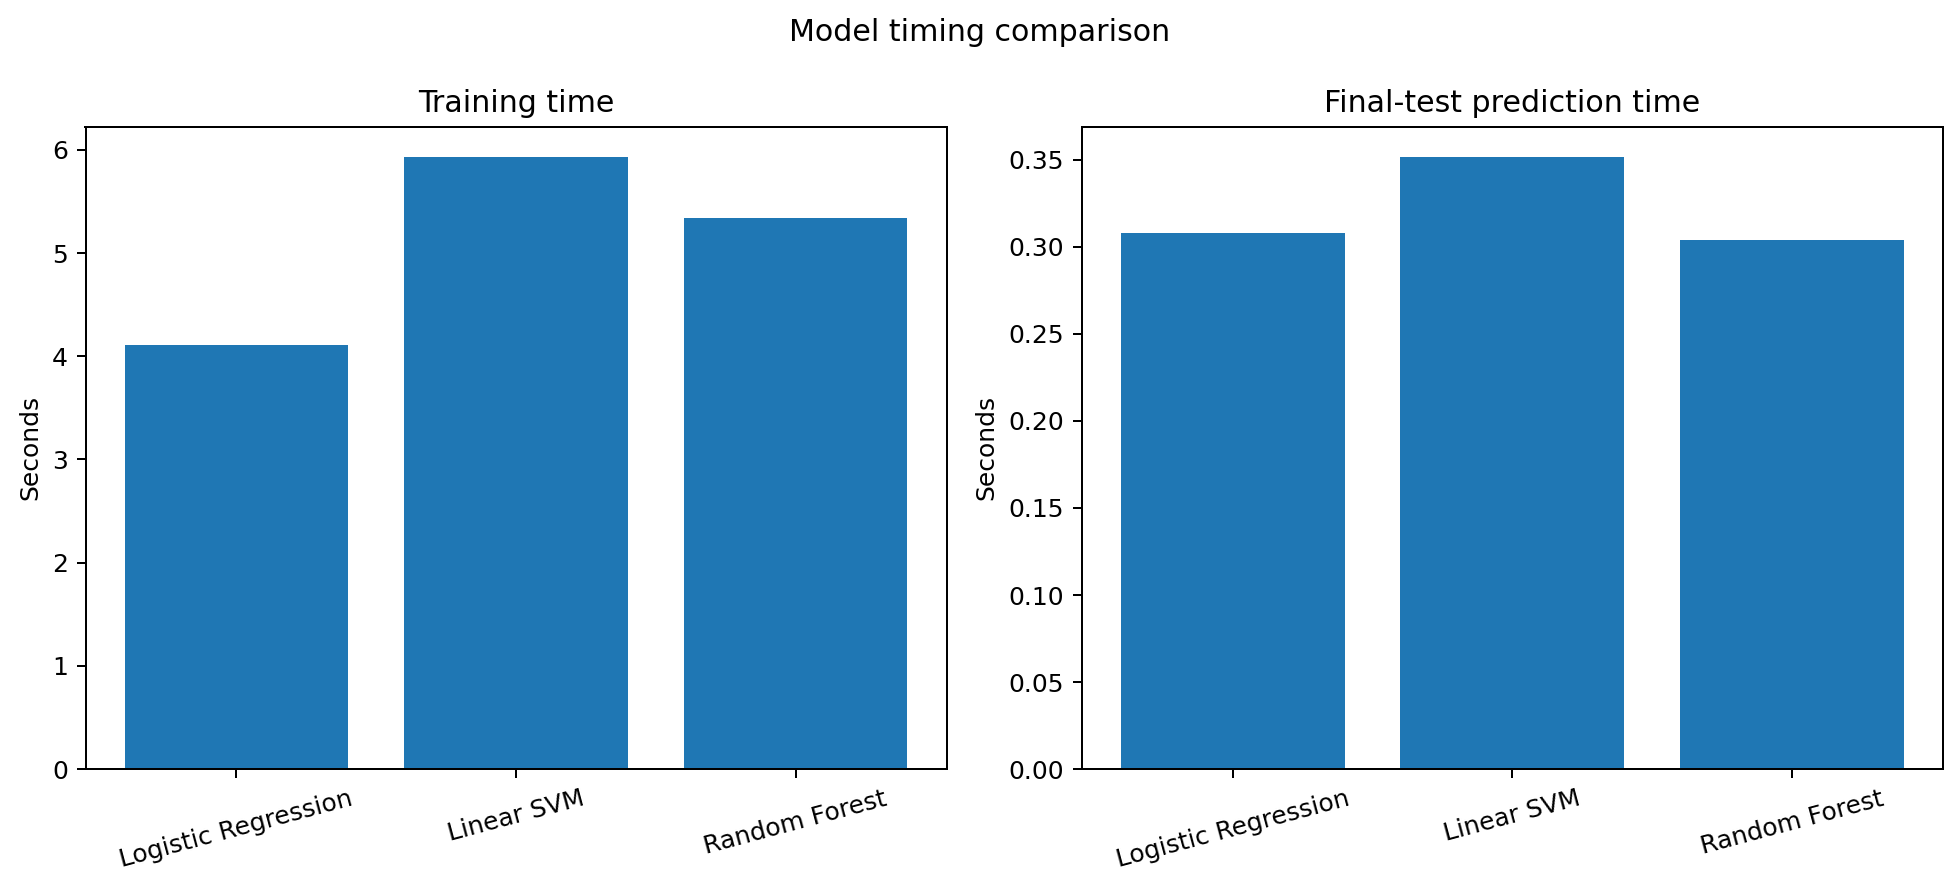

primary_confusion_matrices.png True


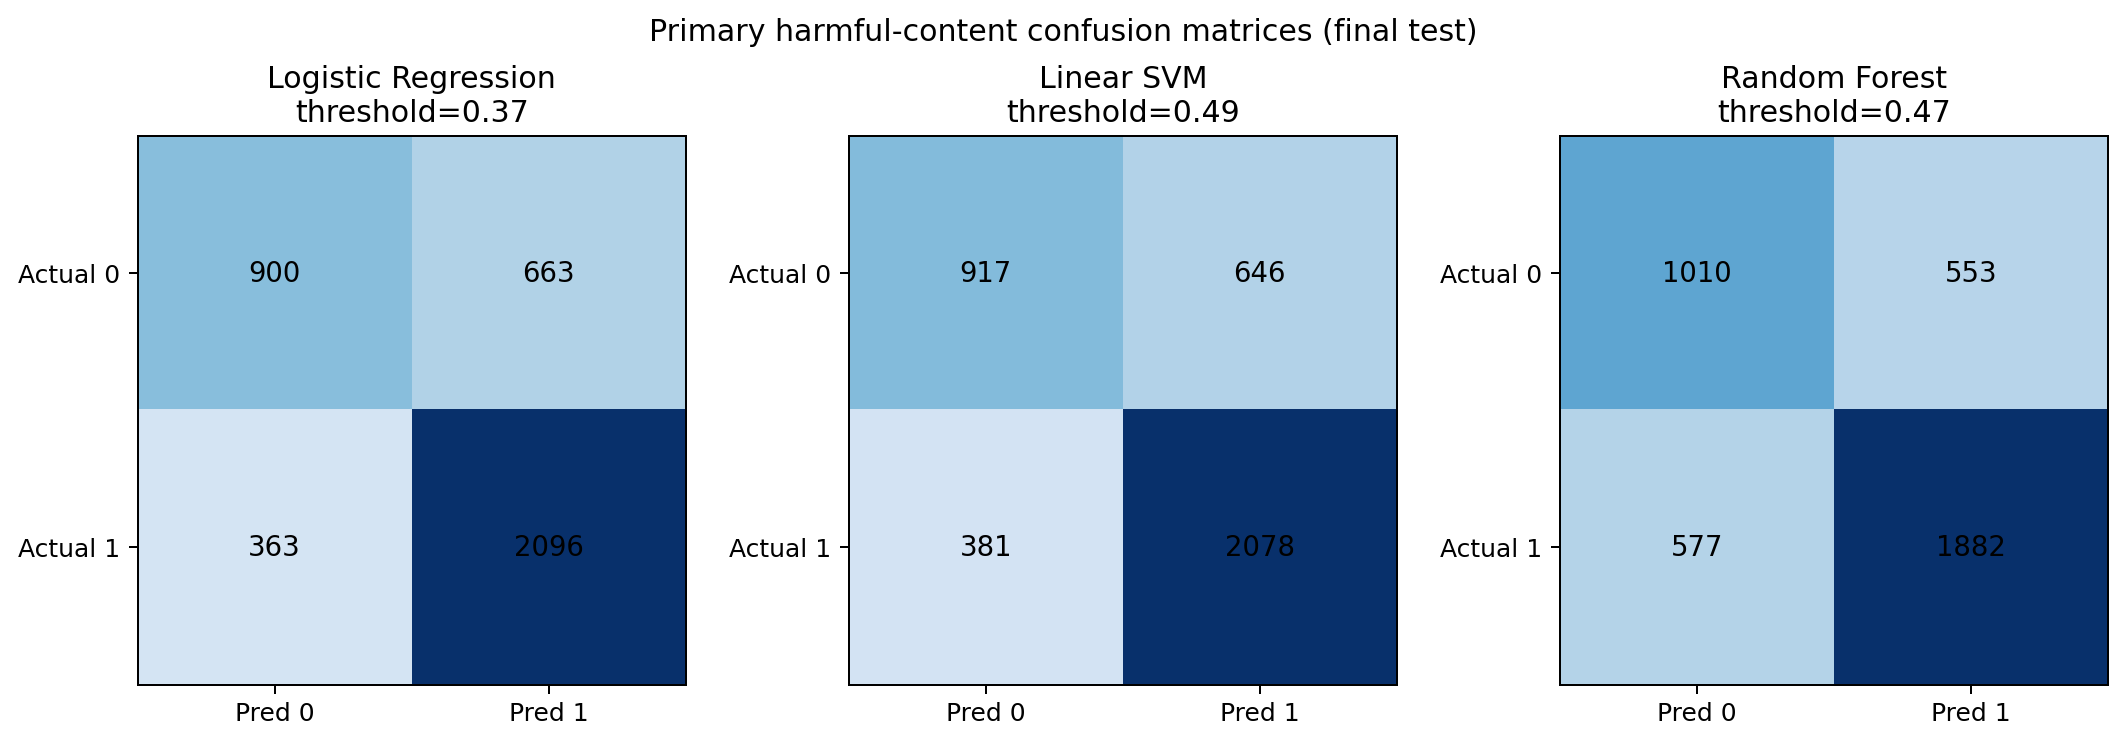

confusion_matrices_multilabel_final_test.png True


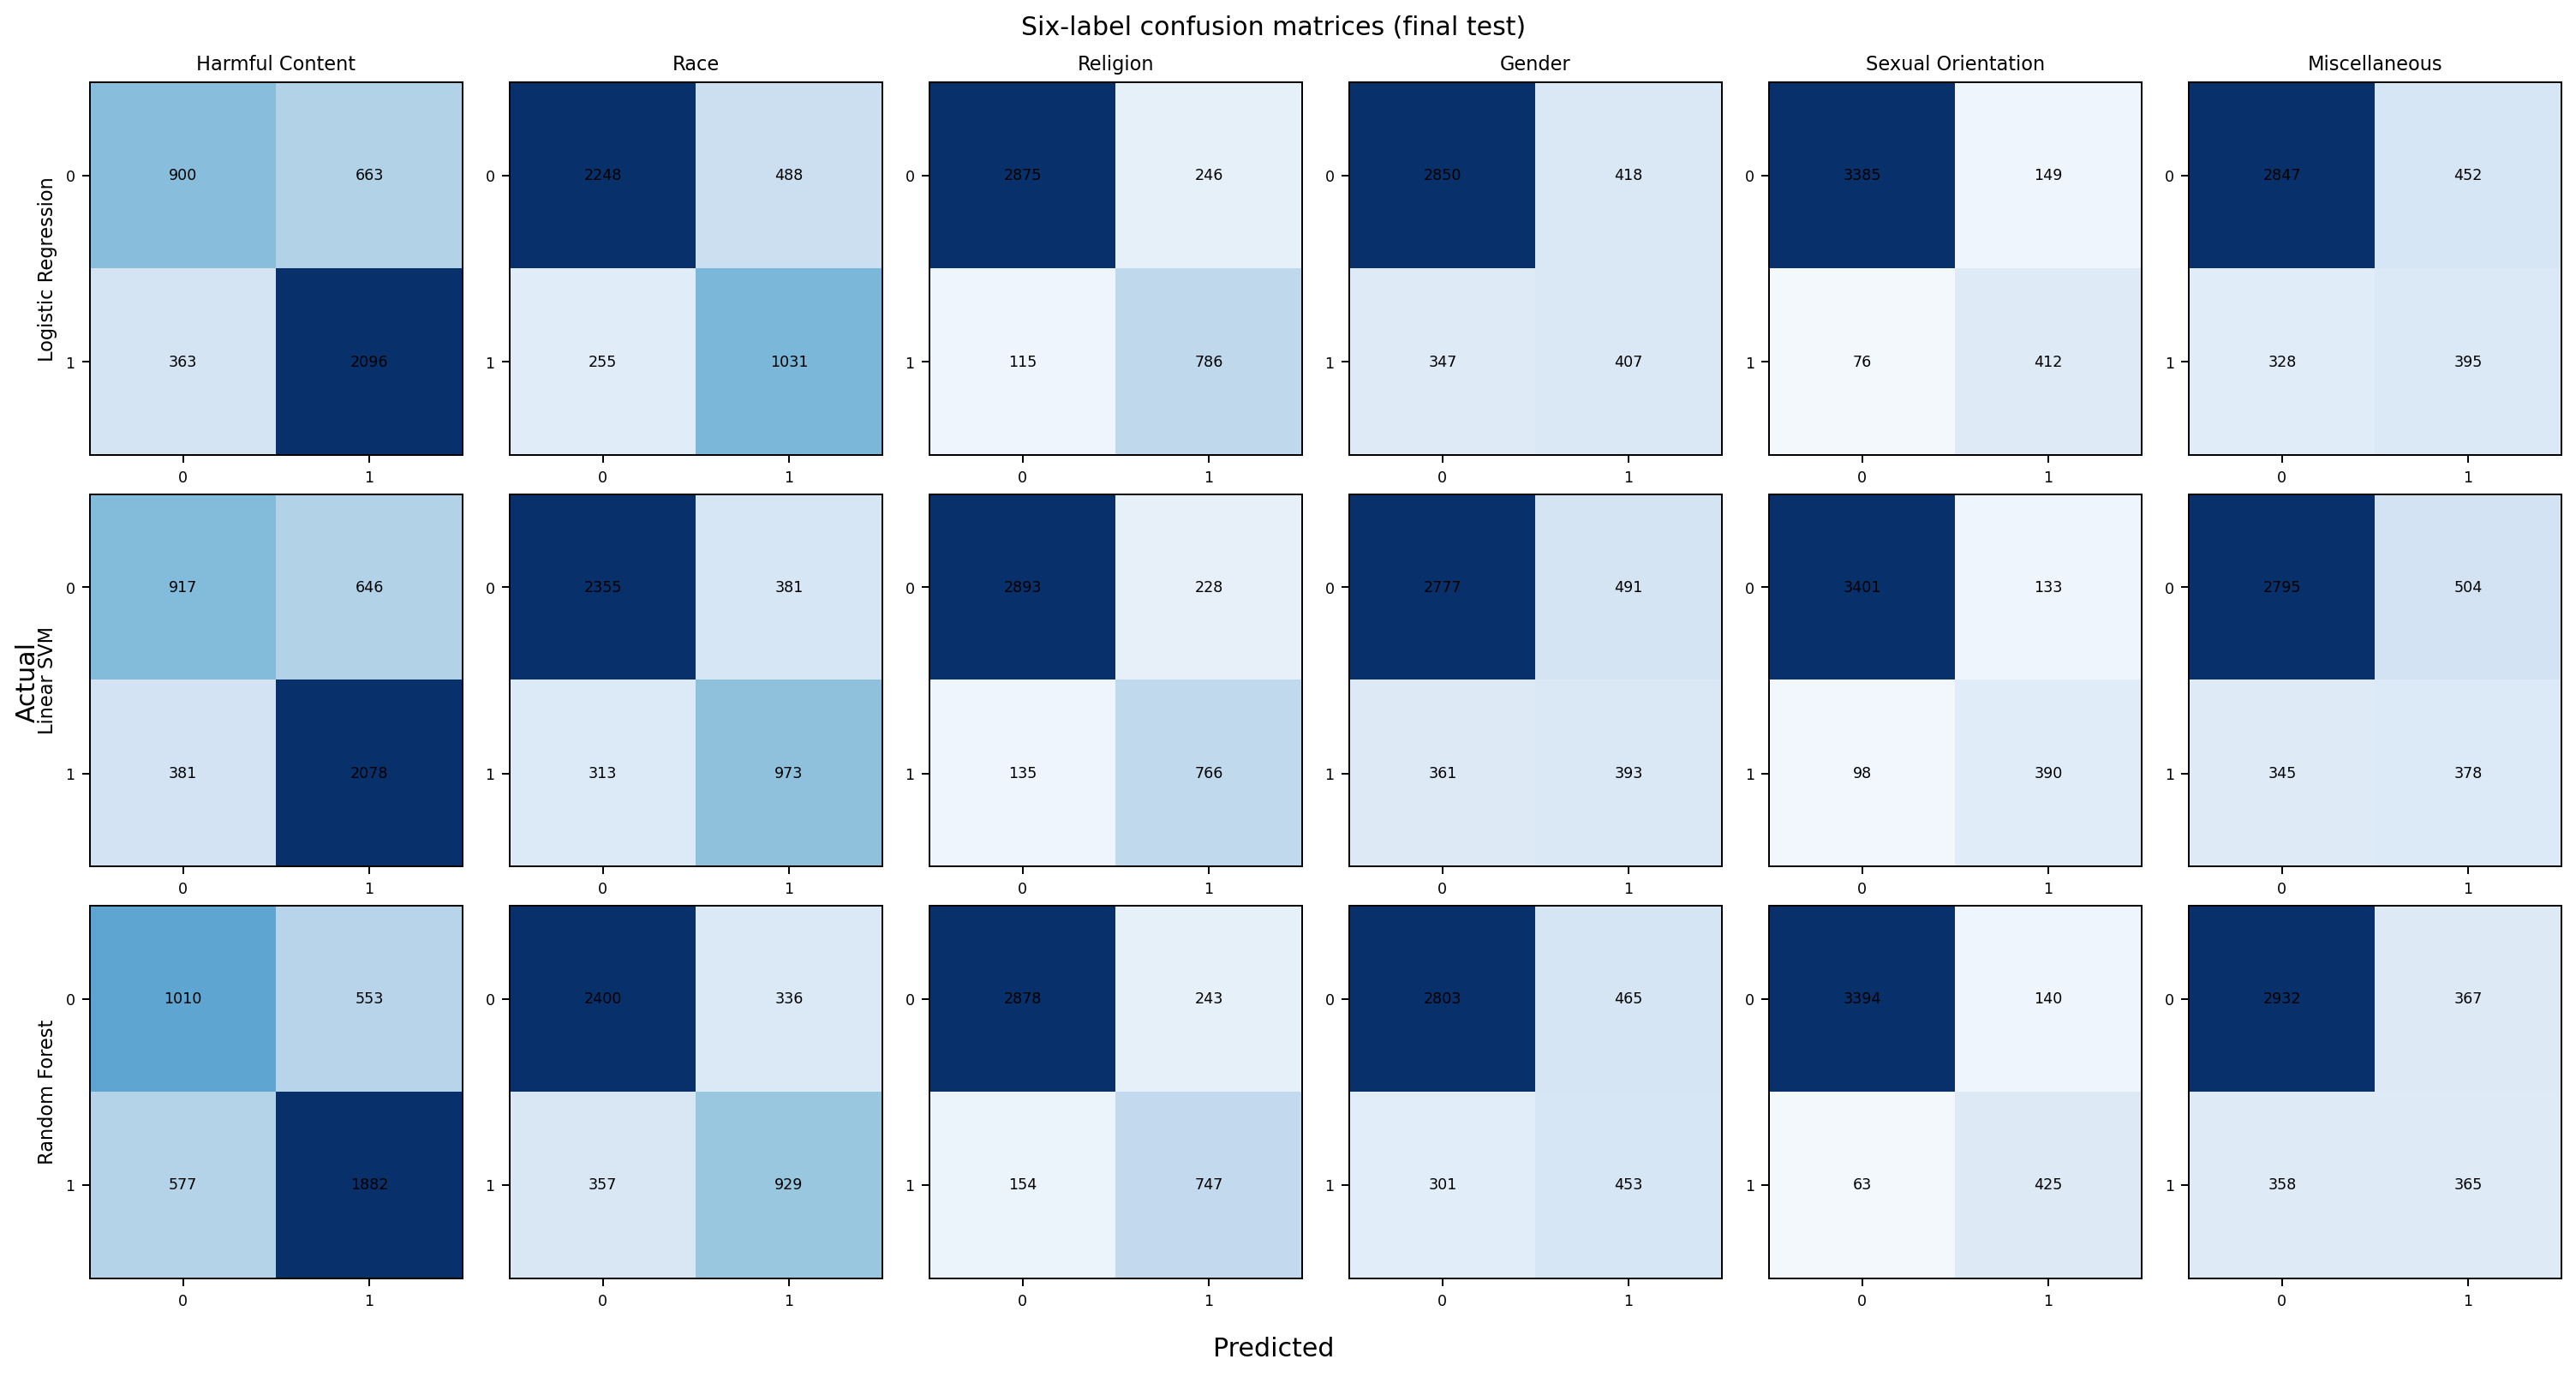

In [13]:
for filename in [
    'primary_metrics_comparison.png','primary_error_rates.png','per_label_f1_heatmap.png',
    'per_label_precision_heatmap.png','per_label_recall_heatmap.png','threshold_comparison.png',
    'oof_vs_final_test_f1.png','model_timing_comparison.png','primary_confusion_matrices.png',
    'confusion_matrices_multilabel_final_test.png']:
    path = RESULTS_DIR / filename
    print(filename, path.exists())
    if path.exists(): display(Image(filename=str(path)))


## 12. Per-label results

Per-label CSVs provide precision, recall, F1, support, FPR/FNR, confusion counts and thresholds. Gender and Miscellaneous remain weaker outputs in the supplied final-test evidence.


In [14]:
for filename in ['per_label_logistic_regression.csv','per_label_linear_svm.csv','per_label_random_forest.csv']:
    print(filename)
    display(pd.read_csv(RESULTS_DIR / filename)[['label','threshold','precision','recall','f1','support','false_positive_rate','false_negative_rate']])


per_label_logistic_regression.csv


,label,threshold,precision,recall,f1,support,false_positive_rate,false_negative_rate
0,abusive,0.37,0.759696,0.852379,0.803373,2459,0.424184,0.147621
1,Race,0.46,0.678736,0.801711,0.735116,1286,0.178363,0.198289
2,Religion,0.47,0.761628,0.872364,0.813244,901,0.078821,0.127636
3,Gender,0.58,0.493333,0.539788,0.515516,754,0.127907,0.460212
4,Sexual_Orientation,0.53,0.734403,0.844262,0.785510,488,0.042162,0.155738
5,Miscellaneous,0.56,0.466352,0.546335,0.503185,723,0.137011,0.453665


per_label_linear_svm.csv


,label,threshold,precision,recall,f1,support,false_positive_rate,false_negative_rate
0,abusive,0.49,0.762849,0.845059,0.801852,2459,0.413308,0.154941
1,Race,0.37,0.718612,0.756610,0.737121,1286,0.139254,0.243390
2,Religion,0.30,0.770624,0.850166,0.808443,901,0.073054,0.149834
3,Gender,0.25,0.444570,0.521220,0.479853,754,0.150245,0.478780
4,Sexual_Orientation,0.23,0.745698,0.799180,0.771513,488,0.037634,0.200820
5,Miscellaneous,0.23,0.428571,0.522822,0.471028,723,0.152774,0.477178


per_label_random_forest.csv


,label,threshold,precision,recall,f1,support,false_positive_rate,false_negative_rate
0,abusive,0.47,0.772895,0.765352,0.769105,2459,0.353807,0.234648
1,Race,0.49,0.734387,0.722395,0.728342,1286,0.122807,0.277605
2,Religion,0.48,0.754545,0.829079,0.790058,901,0.077860,0.170921
3,Gender,0.48,0.493464,0.600796,0.541866,754,0.142289,0.399204
4,Sexual_Orientation,0.48,0.752212,0.870902,0.807217,488,0.039615,0.129098
5,Miscellaneous,0.49,0.498634,0.504841,0.501718,723,0.111246,0.495159


## 13. Confusion matrices

The primary confusion figure reports binary `abusive` errors. The multilabel figure shows all six output confusion matrices from the saved final-test evidence.


## 14. Regression Example Testing

Only the three required regression examples are checked. They do not influence training or threshold selection.


In [15]:
regression_examples = [
    'you are a stupid idiot nobody likes you',
    'Thanks for sharing, this was really useful!',
    "go back to your own country you don't belong here",
]
rows = []
for text in regression_examples:
    row = {'text': text}
    for model_name, model_path in available_models().items():
        bundle = load_model(model_path)
        result = predict(bundle, text)
        row[model_name] = 'YES' if result['is_harmful'] else 'NO'
        row[f'{model_name} probability'] = round(result['harmful_probability'], 4)
        row[f'{model_name} threshold'] = result['harmful_threshold']
    rows.append(row)
regression_df = pd.DataFrame(rows)
display(regression_df)


,text,Logistic Regression,Logistic Regression probability,Logistic Regression threshold,Linear SVM,Linear SVM probability,Linear SVM threshold,Random Forest,Random Forest probability,Random Forest threshold
0,you are a stupid idiot nobody likes you,YES,0.3991,0.37,YES,0.5300,0.49,YES,0.5444,0.47
1,"Thanks for sharing, this was really useful!",NO,0.2017,0.37,NO,0.2765,0.49,NO,0.4648,0.47
2,go back to your own country you don't belong here,YES,0.5203,0.37,YES,0.5342,0.49,YES,0.4804,0.47


In [16]:
for text in regression_examples:
    assert not raw['comment'].fillna('').astype(str).eq(text).any()
print('All three exact examples are absent from final_hateXplain.csv.')


All three exact examples are absent from final_hateXplain.csv.


## 15. Model comparison and preferred model

Logistic Regression remains the preferred/default model because the supplied final-test evidence gives it the highest harmful-content F1 (0.8034) and multilabel micro-F1 (0.7245). SVM is close on harmful-content metrics; Random Forest has the lowest benign FPR but lower harmful-content recall/F1.


## 16. Limitations

- HateXplain is not a dedicated cyberbullying dataset and contains individual posts rather than conversation history.
- The system is English-only and based on short social-media text.
- Target-community labels can occur in normal posts and harmful posts can exist without a mapped target.
- Gender and Miscellaneous are weaker outputs in the supplied final-test evidence.
- Model explanations are feature contributions rather than causal explanations.
- Statistical predictions can be wrong and require human judgement.


## 17. Conclusion

The project preserves the leakage-safe 80/20 split, five-fold model-selection CV, and separate five-fold OOF threshold selection. It compares Logistic Regression, calibrated Linear SVM and Random Forest, documents the final evidence, and retains the three regression examples as a separate smoke/regression check.


### Full retraining remains disabled

Set `RUN_FULL_RETRAINING = True` only when an intentional full retraining run is required; otherwise the notebook uses the existing saved results.


In [17]:
# EXPLICIT_FULL_RETRAINING_GATE
if RUN_FULL_RETRAINING:
    import subprocess, sys
    for module in [
        'models.member1_logistic_regression',
        'models.member2_svm',
        'models.member3_random_forest',
    ]:
        subprocess.run([sys.executable, '-m', module], check=True)
    subprocess.run([sys.executable, 'compare_models.py'], check=True)
    subprocess.run([sys.executable, 'generate_final_artifacts.py'], check=True)
else:
    print('Full retraining is disabled; using existing saved models/results.')


Full retraining is disabled; using existing saved models/results.
